In [2]:
import os
import wfdb
import pandas as pd
print(os.getcwd())

/Users/oscarvalcarcegonzalez/Documents/URJC/APII/ecg-anomaly-detection-openset/notebooks


# Datos y análisis inicial

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  
data_dir = PROJECT_ROOT / 'data' / 'raw' / 'mitdb'

print(f" Dir: {data_dir}")
print(f"¿Existe la carpeta?: {data_dir.exists()}")

records = sorted(set(p.stem for p in data_dir.glob('*.dat')))
print(f"Num registros: {len(records)}")

 Dir: /Users/oscarvalcarcegonzalez/Documents/URJC/APII/ecg-anomaly-detection-openset/data/raw/mitdb
¿Existe la carpeta?: True
Num registros: 48


In [4]:
record = wfdb.rdrecord(str(data_dir / records[0]))
annotation = wfdb.rdann(str(data_dir / records[0]), 'atr')

print(f"Frecuencia de muestreo: {record.fs} Hz")
print(f"Duración: {record.sig_len / record.fs / 60:.1f} minutos")
print(f"Canales: {record.sig_name}")
print(f"Número de latidos anotados: {len(annotation.sample)}")
print(f"Tipos de latido presentes: {set(annotation.symbol)}")

Frecuencia de muestreo: 360 Hz
Duración: 30.1 minutos
Canales: ['MLII', 'V5']
Número de latidos anotados: 2274
Tipos de latido presentes: {'N', 'V', '+', 'A'}


In [5]:
from collections import Counter

censo = {}
for rec in records:
    ann = wfdb.rdann(str(data_dir / rec), 'atr')
    censo[rec] = Counter(ann.symbol)

censo_df = pd.DataFrame(censo).fillna(0).astype(int).T
print(censo_df.sum().sort_values(ascending=False))  # totales por tipo de latido

N    75052
L     8075
R     7259
V     7130
/     7028
A     2546
+     1291
f      982
F      803
~      616
!      472
"      437
j      229
x      193
a      150
|      132
E      106
J       83
Q       33
e       16
[        6
]        6
S        2
dtype: int64


In [6]:
import wfdb

record = wfdb.rdrecord(str(data_dir / '102'))
annotation = wfdb.rdann(str(data_dir / '102'), 'atr')

wfdb.plot_wfdb(record=record, annotation=annotation,
               title='Registro 102 - MIT-BIH',
               time_units='seconds')

<Figure size 640x480 with 2 Axes>

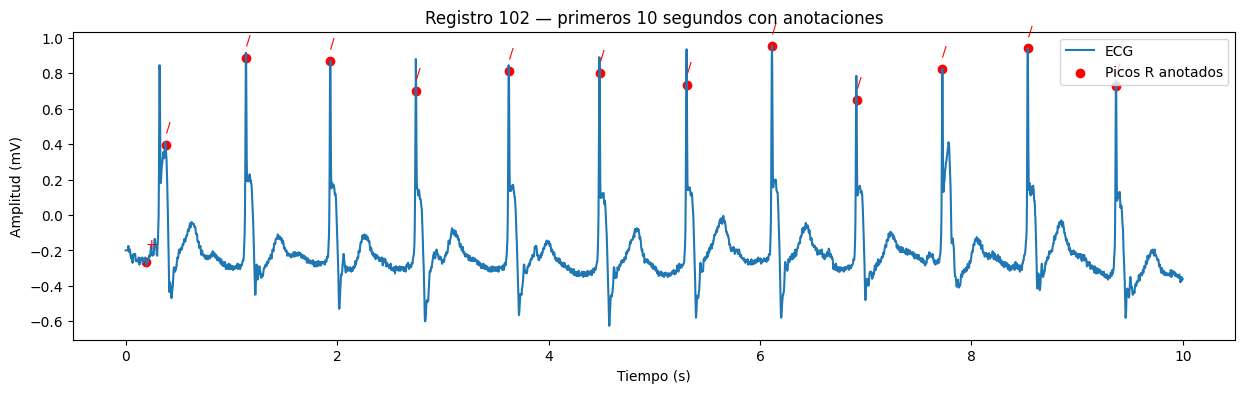

In [7]:
import matplotlib.pyplot as plt
import numpy as np

record = wfdb.rdrecord(str(data_dir / '102'))
annotation = wfdb.rdann(str(data_dir / '102'), 'atr')

# Ventana de 10 segundos 
fs = record.fs
start, end = 0, fs * 10

signal = record.p_signal[start:end, 0]  # canal 0 (normalmente MLII)
tiempo = np.arange(start, end) / fs

plt.figure(figsize=(15, 4))
plt.plot(tiempo, signal, label='ECG')

# Superponer anotaciones dentro de esa ventana
mask = (annotation.sample >= start) & (annotation.sample < end)
picos_r = annotation.sample[mask]
simbolos = np.array(annotation.symbol)[mask]

plt.scatter(picos_r / fs, signal[picos_r - start], c='red', marker='o', label='Picos R anotados')
for p, s in zip(picos_r, simbolos):
    plt.annotate(s, (p / fs, signal[p - start]), textcoords="offset points", xytext=(0, 10), color='red')

plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (mV)')
plt.title('Registro 102 — primeros 10 segundos con anotaciones')
plt.legend()
plt.show()

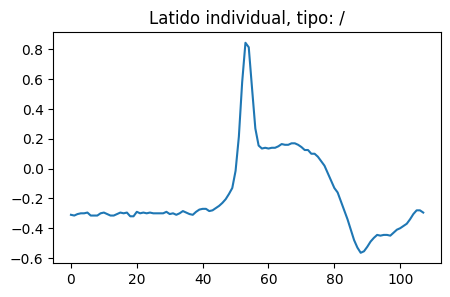

In [8]:
def extraer_latido(signal, pico, fs, ventana_ms=300):
    media_ventana = int(fs * ventana_ms / 1000 / 2)
    return signal[pico - media_ventana : pico + media_ventana]

latido = extraer_latido(record.p_signal[:, 0], picos_r[5], fs)
plt.figure(figsize=(5, 3))
plt.plot(latido)
plt.title(f"Latido individual, tipo: {simbolos[5]}")
plt.show()

In [9]:
import numpy as np

# Usar todas las anotaciones del registro, no una ventana recortada
simbolos_completos = np.array(annotation.symbol)
picos_r_completos = annotation.sample

idx_normal = np.where(simbolos_completos == 'N')[0]
idx_v = np.where(simbolos_completos == 'V')[0]

print(f"Latidos N encontrados: {len(idx_normal)}")
print(f"Latidos V encontrados: {len(idx_v)}")

Latidos N encontrados: 99
Latidos V encontrados: 4


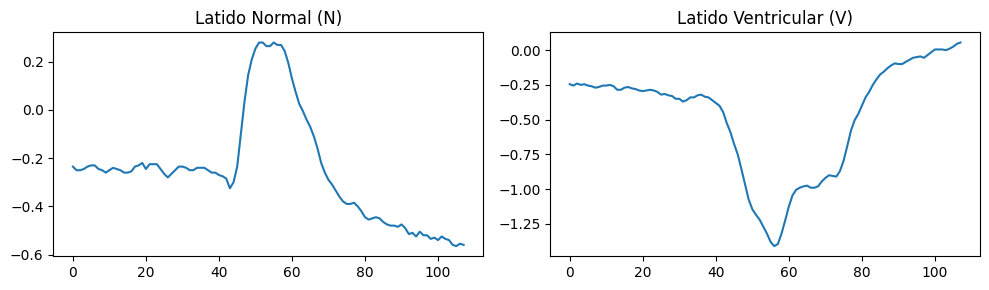

In [10]:
idx_normal = np.where(simbolos_completos == 'N')[0][0]
idx_v = np.where(simbolos_completos == 'V')[0][0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(extraer_latido(record.p_signal[:, 0], picos_r_completos[idx_normal], record.fs))
axes[0].set_title('Latido Normal (N)')
axes[1].plot(extraer_latido(record.p_signal[:, 0], picos_r_completos[idx_v], record.fs))
axes[1].set_title('Latido Ventricular (V)')
plt.tight_layout()
plt.show()

## Filtrado y agrupación AMII


In [11]:
# Símbolos que NO son latidos reales (hay que descartarlos)
NO_LATIDO = {'+', '~', '!', '"', '|', '[', ']'}

# Agrupación AAMI EC57
AAMI_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}

def filtrar_y_mapear(simbolos, picos):
    # Filtrar anotaciones no-latido y mapear a tipología AAMI
    simbolos = np.array(simbolos)
    picos = np.array(picos)

    mask_latido = ~np.isin(simbolos, list(NO_LATIDO))
    simbolos_validos = simbolos[mask_latido]
    picos_validos = picos[mask_latido]

    etiquetas_aami = np.array([AAMI_MAP.get(s, 'Q') for s in simbolos_validos])
    return picos_validos, etiquetas_aami

In [12]:
censo_aami = {}
picos_por_registro = {}
etiquetas_por_registro = {}

for rec in records:
    ann = wfdb.rdann(str(data_dir / rec), 'atr')
    picos_validos, etiquetas_aami = filtrar_y_mapear(ann.symbol, ann.sample)

    picos_por_registro[rec] = picos_validos
    etiquetas_por_registro[rec] = etiquetas_aami
    censo_aami[rec] = Counter(etiquetas_aami)

censo_aami_df = pd.DataFrame(censo_aami).fillna(0).astype(int).T
print(censo_aami_df)
print("\nTotales por superclase:")
print(censo_aami_df.sum().sort_values(ascending=False))

        N     S    V     Q    F
100  2239    33    1     0    0
101  1860     3    0     2    0
102    99     0    4  2084    0
103  2082     2    0     0    0
104   163     0    2  2064    0
105  2526     0   41     5    0
106  1507     0  520     0    0
107     0     0   59  2078    0
108  1740     4   17    11    2
109  2492     0   38     0    2
111  2123     0    1     0    0
112  2537     2    0     0    0
113  1789     6    0     0    0
114  1820    12   43     0    4
115  1953     0    0     0    0
116  2302     1  109     0    0
117  1534     1    0     0    0
118  2166    96   16    10    0
119  1543     0  444     0    0
121  1861     1    1     0    0
122  2476     0    0     0    0
123  1515     0    3     0    0
124  1536    31   47     0    5
200  1743    30  826     0    2
201  1635   128  198    37    2
202  2061    55   19     0    1
203  2529     2  444     4    1
205  2571     3   71     0   11
207  1543   107  210     0    0
208  1586     2  992     2  373
209  262

### Verificar numero de pacientes y excluir (V) 
Es la señal que queremos detectar, por lo tanto no estará presente en el entrenamiento

In [13]:
n_pacientes_con_V = (censo_aami_df['V'] > 0).sum()
print(f"Pacientes con al menos un latido V: {n_pacientes_con_V} de {len(censo_aami_df)}")
print("\nRegistros con más latidos V (candidatos para reservar en test):")
print(censo_aami_df['V'].sort_values(ascending=False).head(10))

Pacientes con al menos un latido V: 37 de 48

Registros con más latidos V (candidatos para reservar en test):
208    992
233    831
200    826
106    520
223    473
203    444
119    444
221    396
228    362
214    256
Name: V, dtype: int64


### Split por paciente

Train: pacientes con abundante N (y otras clases), **excluyendo todo latido V** de estos pacientes.

Test: incluye pacientes con muchos latidos V, para poder evaluar bien la detección de la arritmia "nunca vista".

In [14]:
from sklearn.model_selection import train_test_split

pacientes = censo_aami_df.index.tolist()

# Separar pacientes con más V para garantizar que estén bien representados en test
pacientes_con_V = censo_aami_df[censo_aami_df['V'] > 20].index.tolist()  # umbral ajustable
pacientes_resto = [p for p in pacientes if p not in pacientes_con_V]

# Mitad de los pacientes con V van a test (para asegurar suficientes ejemplos de V en evaluación)
train_extra, test_con_V = train_test_split(pacientes_con_V, test_size=0.5, random_state=42)

# El resto de pacientes se reparte en train/val/test de manera uniforme 70-30
train_resto, val_test_resto = train_test_split(pacientes_resto, test_size=0.3, random_state=42)
val_resto, test_resto = train_test_split(val_test_resto, test_size=0.5, random_state=42)

pacientes_train = train_resto + train_extra
pacientes_val = val_resto
pacientes_test = test_resto + test_con_V

print(f"Train: {len(pacientes_train)} pacientes")
print(f"Val: {len(pacientes_val)} pacientes")
print(f"Test: {len(pacientes_test)} pacientes (incluye los ricos en V)")

Train: 28 pacientes
Val: 4 pacientes
Test: 16 pacientes (incluye los ricos en V)


### Segmentación completa: extraer todos los latidos como tensores

In [15]:
def segmentar_registro(rec_name, ventana_ms=300):
    record = wfdb.rdrecord(str(data_dir / rec_name))
    fs = record.fs
    signal = record.p_signal[:, 0]  # canal principal (normalmente MLII) 

    picos = picos_por_registro[rec_name]
    etiquetas = etiquetas_por_registro[rec_name]

    media_ventana = int(fs * ventana_ms / 1000 / 2)
    latidos, etiquetas_validas = [], []

    for pico, etq in zip(picos, etiquetas):
        if pico - media_ventana < 0 or pico + media_ventana > len(signal):
            continue  # descartar latidos cerca del borde del registro 
        segmento = signal[pico - media_ventana : pico + media_ventana]
        # Normalización por latido
        segmento = (segmento - segmento.mean()) / (segmento.std() + 1e-8)
        latidos.append(segmento)
        etiquetas_validas.append(etq)

    return np.array(latidos), np.array(etiquetas_validas)

# Construir dataset completo por split
def construir_split(lista_pacientes, excluir_clases=None):
    # excluir_clases: lista de etiquetas AAMI a excluir (ej. ['V', 'Q']). None = no excluir nada.
    X, y = [], []
    for rec in lista_pacientes:
        latidos, etiquetas = segmentar_registro(rec)
        if excluir_clases:
            mask = ~np.isin(etiquetas, excluir_clases)
            latidos, etiquetas = latidos[mask], etiquetas[mask]
        X.append(latidos)
        y.append(etiquetas)
    return np.concatenate(X), np.concatenate(y)

X_train, y_train = construir_split(pacientes_train, excluir_clases=['V', 'Q'])
X_val, y_val = construir_split(pacientes_val, excluir_clases=['V', 'Q'])
X_test, y_test = construir_split(pacientes_test, excluir_clases=None)  # test SI incluye TODO (V y Q incluidos)

print(f"Train: {X_train.shape}, clases: {Counter(y_train)}")
print(f"Val: {X_val.shape}, clases: {Counter(y_val)}")
print(f"Test: {X_test.shape}, clases: {Counter(y_test)}")

Train: (56088, 108), clases: Counter({'N': 53866, 'S': 1822, 'F': 400})
Val: (9056, 108), clases: Counter({'N': 8833, 'S': 223})
Test: (36908, 108), clases: Counter({'N': 27924, 'Q': 3928, 'V': 3918, 'S': 736, 'F': 402})


### Guardar los arrays procesados (para no repetir esto cada vez)

In [16]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # sube de notebooks/ a Proyecto/
processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)  # crea la carpeta si no existe

np.savez(processed_dir / 'ecg_splits.npz',
          X_train=X_train, y_train=y_train,
          X_val=X_val, y_val=y_val,
          X_test=X_test, y_test=y_test)

print(f"Guardado en: {processed_dir / 'ecg_splits.npz'}")

Guardado en: /Users/oscarvalcarcegonzalez/Documents/URJC/APII/ecg-anomaly-detection-openset/data/processed/ecg_splits.npz


In [17]:
print(f"¿Existe el fichero?: {(processed_dir / 'ecg_splits.npz').exists()}")

# Comprobación de carga
data = np.load(processed_dir / 'ecg_splits.npz')
print(list(data.keys()))
print(f"X_train shape: {data['X_train'].shape}")

¿Existe el fichero?: True
['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']
X_train shape: (56088, 108)


108 muestras por latido. MIT-BIH tiene una frecuencia de muestreo de 360 Hz, y con una ventana de 300 ms (ventana_ms=300), el cálculo es:

media_ventana = int(360 * 300 / 1000 / 2) = int(54) = 54
ventana total = 54 * 2 = 108 muestras

(a, 108) : a latidos en train, cada uno representado por una ventana de 108 puntos de señal centrada en el pico R. Todo correcto.

#### Revision val y test

In [18]:
print(f"X_train: {data['X_train'].shape}, clases train: {Counter(data['y_train'].tolist())}")
print(f"X_val: {data['X_val'].shape}, clases val: {Counter(data['y_val'].tolist())}")
print(f"X_test: {data['X_test'].shape}, clases test: {Counter(data['y_test'].tolist())}")

X_train: (56088, 108), clases train: Counter({'N': 53866, 'S': 1822, 'F': 400})
X_val: (9056, 108), clases val: Counter({'N': 8833, 'S': 223})
X_test: (36908, 108), clases test: Counter({'N': 27924, 'Q': 3928, 'V': 3918, 'S': 736, 'F': 402})


# 1. Exploración estadística

## Tabla resumen

In [19]:
import pandas as pd

resumen = pd.DataFrame({
    'Train': pd.Series(Counter(y_train)),
    'Val': pd.Series(Counter(y_val)),
    'Test': pd.Series(Counter(y_test)),
}).fillna(0).astype(int)

resumen['Total'] = resumen.sum(axis=1)
resumen.loc['TOTAL'] = resumen.sum()
print(resumen)

# Proporciones dentro de cada split
proporciones = resumen.div(resumen.loc['TOTAL'], axis=1) * 100
print("\nProporciones (%):")
print(proporciones.round(2))

       Train   Val   Test   Total
F        400     0    402     802
N      53866  8833  27924   90623
Q          0     0   3928    3928
S       1822   223    736    2781
V          0     0   3918    3918
TOTAL  56088  9056  36908  102052

Proporciones (%):
        Train     Val    Test   Total
F        0.71    0.00    1.09    0.79
N       96.04   97.54   75.66   88.80
Q        0.00    0.00   10.64    3.85
S        3.25    2.46    1.99    2.73
V        0.00    0.00   10.62    3.84
TOTAL  100.00  100.00  100.00  100.00


## Valores faltantes

In [20]:
# Detección de outliers/latidos planos SOBRE SEÑAL CRUDA (antes de normalizar)
def detectar_calidad_cruda(rec_names, ventana_ms=300, umbral_std_plano=0.01, umbral_amplitud=10):
    resultados = []
    for rec in rec_names:
        record = wfdb.rdrecord(str(data_dir / rec))
        signal = record.p_signal[:, 0]
        fs = record.fs
        media_ventana = int(fs * ventana_ms / 1000 / 2)

        picos = picos_por_registro[rec]
        etiquetas = etiquetas_por_registro[rec]

        for pico, etq in zip(picos, etiquetas):
            if pico - media_ventana < 0 or pico + media_ventana > len(signal):
                continue
            segmento_crudo = signal[pico - media_ventana: pico + media_ventana]
            resultados.append({
                'registro': rec,
                'clase': etq,
                'std_crudo': segmento_crudo.std(),
                'rango_crudo': segmento_crudo.max() - segmento_crudo.min(),
            })
    return pd.DataFrame(resultados)

calidad_df = detectar_calidad_cruda(pacientes_train + pacientes_val + pacientes_test)

planos = calidad_df[calidad_df['std_crudo'] < 0.01]
print(f"Latidos con std crudo < 0.01 mV: {len(planos)} de {len(calidad_df)} ({len(planos)/len(calidad_df)*100:.3f}%)")
print(planos['clase'].value_counts())

Latidos con std crudo < 0.01 mV: 2 de 109677 (0.002%)
clase
N    2
Name: count, dtype: int64


## Outliers de amplitud

In [21]:
print(calidad_df['rango_crudo'].describe())

# Percentiles altos
for p in [95, 99, 99.5, 99.9]:
    print(f"Percentil {p}: {calidad_df['rango_crudo'].quantile(p/100):.3f} mV")

count    109677.000000
mean          2.047216
std           0.825815
min           0.025000
25%           1.420000
50%           1.915000
75%           2.540000
max           6.050000
Name: rango_crudo, dtype: float64
Percentil 95: 3.490 mV
Percentil 99: 4.495 mV
Percentil 99.5: 4.695 mV
Percentil 99.9: 5.005 mV


In [22]:
umbral_amplitud = 5

outliers_amplitud = calidad_df[calidad_df['rango_crudo'] > umbral_amplitud]
print(f"Latidos con rango crudo > {umbral_amplitud} mV: {len(outliers_amplitud)} de {len(calidad_df)} ({len(outliers_amplitud)/len(calidad_df)*100:.3f}%)")
if len(outliers_amplitud) > 0:
    print(outliers_amplitud['clase'].value_counts())
    print(f"\nRango máximo encontrado: {calidad_df['rango_crudo'].max():.2f} mV")

Latidos con rango crudo > 5 mV: 112 de 109677 (0.102%)
clase
Q    109
V      2
N      1
Name: count, dtype: int64

Rango máximo encontrado: 6.05 mV


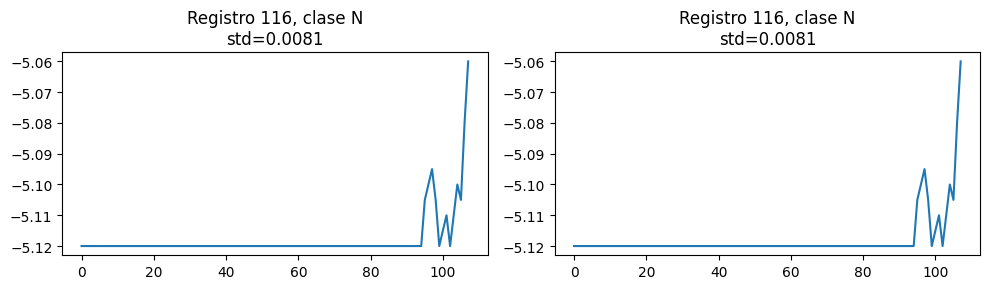

In [23]:
# Recuperamos los índices exactos de los 2 latidos planos para verlos
registros_planos = planos[['registro', 'clase']].values

fig, axes = plt.subplots(1, len(registros_planos), figsize=(5*len(registros_planos), 3))
if len(registros_planos) == 1:
    axes = [axes]

for i, (rec, clase) in enumerate(registros_planos):
    record = wfdb.rdrecord(str(data_dir / rec))
    signal = record.p_signal[:, 0]
    fs = record.fs
    picos = picos_por_registro[rec]
    etiquetas = etiquetas_por_registro[rec]

    # Encontrar el pico concreto que dio std bajo 
    media_ventana = int(fs * 300 / 1000 / 2)
    for pico, etq in zip(picos, etiquetas):
        if etq != clase:
            continue
        if pico - media_ventana < 0 or pico + media_ventana > len(signal):
            continue
        segmento = signal[pico - media_ventana: pico + media_ventana]
        if segmento.std() < 0.01:
            axes[i].plot(segmento)
            axes[i].set_title(f'Registro {rec}, clase {clase}\nstd={segmento.std():.4f}')
            break

plt.tight_layout()
plt.show()

## Eliminación valores faltantes

In [24]:
def segmentar_registro(rec_name, ventana_ms=300, umbral_std_plano=0.01):
    record = wfdb.rdrecord(str(data_dir / rec_name))
    fs = record.fs
    signal = record.p_signal[:, 0]  # canal principal (normalmente MLII)

    picos = picos_por_registro[rec_name]
    etiquetas = etiquetas_por_registro[rec_name]

    media_ventana = int(fs * ventana_ms / 1000 / 2)
    latidos, etiquetas_validas = [], []
    n_descartados_borde = 0
    n_descartados_planos = 0

    for pico, etq in zip(picos, etiquetas):
        if pico - media_ventana < 0 or pico + media_ventana > len(signal):
            n_descartados_borde += 1
            continue  # descartar latidos cerca del borde del registro

        segmento_crudo = signal[pico - media_ventana : pico + media_ventana]

        #  Filtro de calidad - descartar ANTES de normalizar
        if segmento_crudo.std() < umbral_std_plano:
            n_descartados_planos += 1
            continue

        # Normalización por latido 
        segmento = (segmento_crudo - segmento_crudo.mean()) / (segmento_crudo.std() + 1e-8)
        latidos.append(segmento)
        etiquetas_validas.append(etq)

    if n_descartados_planos > 0:
        print(f"  [{rec_name}] descartados {n_descartados_planos} latidos planos (std < {umbral_std_plano})")

    return np.array(latidos), np.array(etiquetas_validas)

## Sanity check normalización

In [25]:
import numpy as np

def verificar_normalizacion(X, nombre):
    medias = X.mean(axis=1)
    stds = X.std(axis=1)
    n_nan = np.isnan(X).sum()
    n_inf = np.isinf(X).sum()
    print(f"--- {nombre} ---")
    print(f"Media de las medias por latido: {medias.mean():.4f} ")
    print(f"Media de las std por latido: {stds.mean():.4f} ")
    print(f"NaNs: {n_nan}, Infs: {n_inf}")
    print()

verificar_normalizacion(X_train, "Train")
verificar_normalizacion(X_val, "Val")
verificar_normalizacion(X_test, "Test")

--- Train ---
Media de las medias por latido: -0.0000 
Media de las std por latido: 1.0000 
NaNs: 0, Infs: 0

--- Val ---
Media de las medias por latido: -0.0000 
Media de las std por latido: 1.0000 
NaNs: 0, Infs: 0

--- Test ---
Media de las medias por latido: -0.0000 
Media de las std por latido: 1.0000 
NaNs: 0, Infs: 0



## Distribución

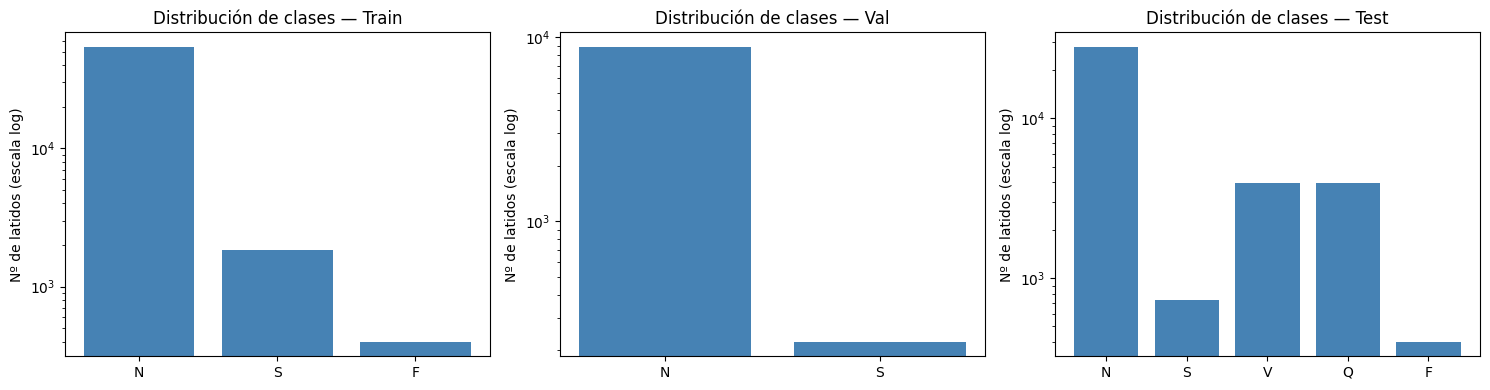

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (split_name, y) in enumerate([('Train', y_train), ('Val', y_val), ('Test', y_test)]):
    counts = Counter(y)
    ax[i].bar(counts.keys(), counts.values(), color='steelblue')
    ax[i].set_title(f'Distribución de clases — {split_name}')
    ax[i].set_yscale('log')  # escala log porque N domina masivamente
    ax[i].set_ylabel('Nº de latidos (escala log)')
plt.tight_layout()
plt.show()

## Forma de onda promedio
V tiene una morfología distinta de N, lo cual es la premisa de que el autoencoder pueda detectarla como anómala:

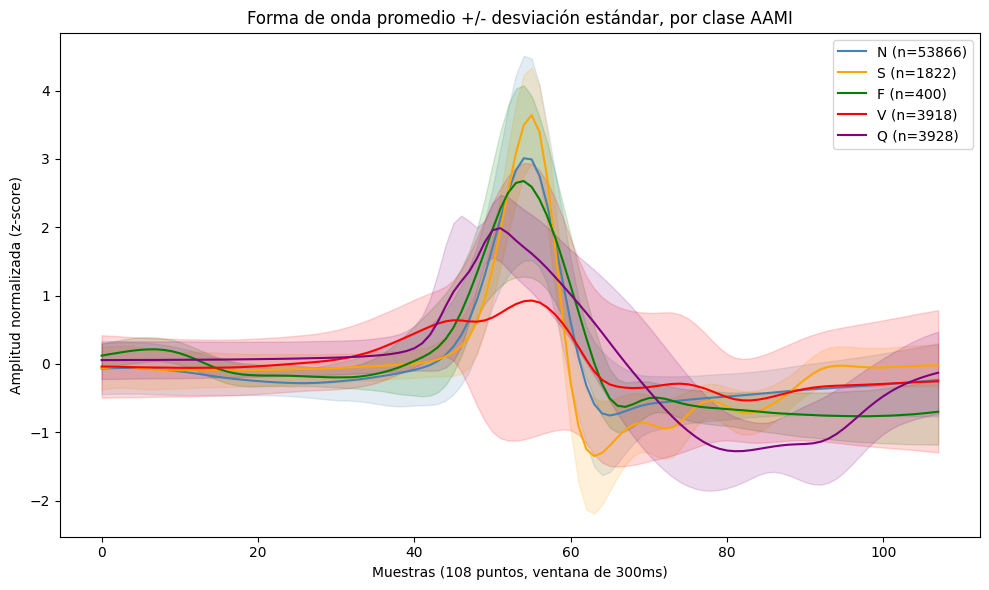

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

clases_a_graficar = ['N', 'S', 'F', 'V', 'Q']
colores = {'N': 'steelblue', 'S': 'orange', 'F': 'green', 'V': 'red', 'Q': 'purple'}

for clase in clases_a_graficar:
    if clase in ['V', 'Q']:
        mask = y_test == clase
        ejemplos = X_test[mask]
    else:
        mask = y_train == clase
        ejemplos = X_train[mask]

    if len(ejemplos) == 0:
        continue

    media = ejemplos.mean(axis=0)
    std = ejemplos.std(axis=0)
    x_axis = np.arange(len(media))

    ax.plot(x_axis, media, label=f'{clase} (n={len(ejemplos)})', color=colores[clase])
    ax.fill_between(x_axis, media - std, media + std, alpha=0.15, color=colores[clase])

ax.set_title('Forma de onda promedio +/- desviación estándar, por clase AAMI')
ax.set_xlabel('Muestras (108 puntos, ventana de 300ms)')
ax.set_ylabel('Amplitud normalizada (z-score)')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
import plotly.graph_objects as go

fig = go.Figure()

colores_plotly = {
    'N': '#1f77ff',   # azul vivo
    'S': '#ff8c00',   # naranja intenso
    'F': '#00b300',   # verde vivo
    'V': '#ff0000',   # rojo puro
    'Q': '#9400d3',   # púrpura intenso
}
for clase in clases_a_graficar:
    if clase in ['V', 'Q']:
        ejemplos = X_test[y_test == clase]
    else:
        ejemplos = X_train[y_train == clase]

    if len(ejemplos) == 0:
        continue

    media = ejemplos.mean(axis=0)
    std = ejemplos.std(axis=0)
    x_axis = list(range(len(media)))
    color = colores_plotly[clase]

    # Banda de +-1 std (área sombreada)
    fig.add_trace(go.Scatter(
        x=x_axis + x_axis[::-1],
        y=list(media + std) + list((media - std)[::-1]),
        fill='toself',
        fillcolor=color,
        opacity=0.15,
        line=dict(width=0),
        showlegend=False,
        hoverinfo='skip',
        legendgroup=clase,
    ))

    # Línea de la media
    fig.add_trace(go.Scatter(
        x=x_axis, y=media,
        mode='lines',
        name=f'{clase} (n={len(ejemplos)})',
        line=dict(color=color, width=2.5),
        legendgroup=clase,
    ))

fig.update_layout(
    title='Forma de onda promedio ± desviación estándar, por clase AAMI (interactivo)',
    xaxis_title='Muestras (108 puntos, ventana de 300ms)',
    yaxis_title='Amplitud normalizada (z-score)',
    height=600,
    template='plotly_white',
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    legend=dict(
        title='Clase',
        orientation='h',        # leyenda horizontal en vez de vertical
        yanchor='top',
        y=-0.15,                # la baja por debajo del área de trazado
        xanchor='center',
        x=0.5,                  # la centra horizontalmente
    ),
    margin=dict(l=40, r=40, t=60, b=80),  # más margen inferior para que quepa la leyenda
)


import plotly.io as pio
pio.renderers.default = 'notebook'  # o 'vscode' si usas la extensión de Jupyter en VSCode
fig.show()

## Proyección PCA — ¿son separables las clases en 2D?



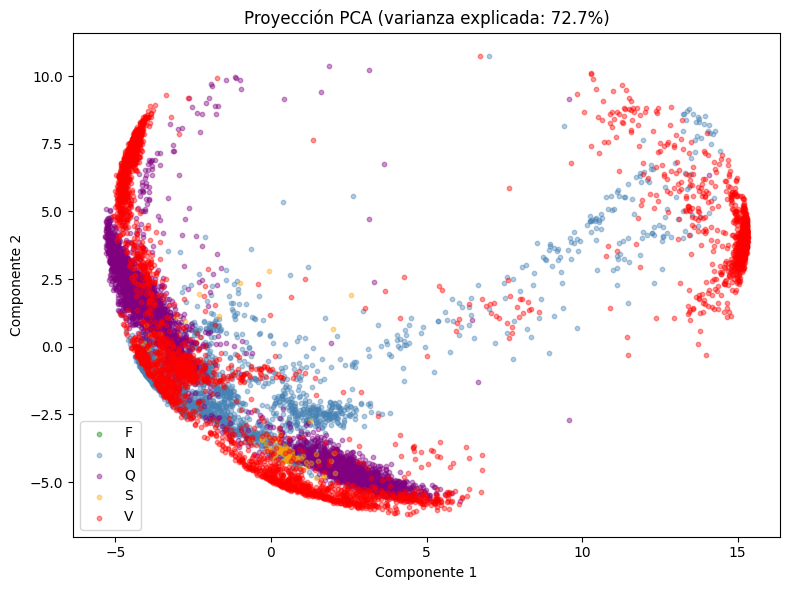

In [29]:
from sklearn.decomposition import PCA

# Combinar una muestra de cada clase para no saturar el gráfico ni el cálculo
np.random.seed(42)
muestra_idx_train = np.random.choice(len(X_train), size=min(3000, len(X_train)), replace=False)
X_muestra = np.vstack([X_train[muestra_idx_train], X_test[y_test == 'V'], X_test[y_test == 'Q']])
y_muestra = np.concatenate([y_train[muestra_idx_train], y_test[y_test == 'V'], y_test[y_test == 'Q']])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_muestra)

fig, ax = plt.subplots(figsize=(8, 6))
for clase in np.unique(y_muestra):
    mask = y_muestra == clase
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=clase, alpha=0.4, s=10, color=colores.get(clase, 'gray'))

ax.set_title(f'Proyección PCA (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})')
ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.legend()
plt.tight_layout()
plt.show()

### 3D

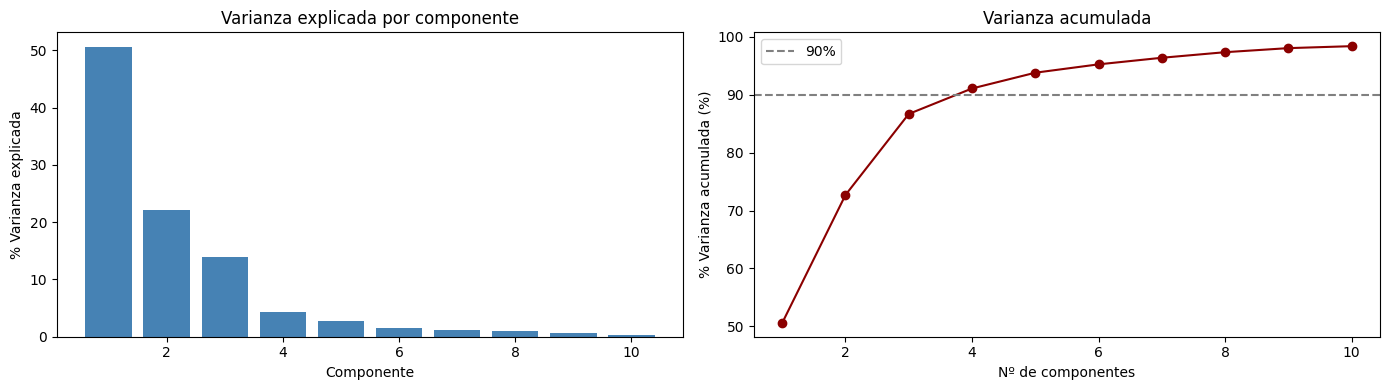

In [30]:
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# --- Scree plot: cuánta varianza aporta cada componente ---
pca_completo = PCA(n_components=10)
pca_completo.fit(X_muestra)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(range(1, 11), pca_completo.explained_variance_ratio_ * 100, color='steelblue')
ax[0].set_title('Varianza explicada por componente')
ax[0].set_xlabel('Componente')
ax[0].set_ylabel('% Varianza explicada')

ax[1].plot(range(1, 11), np.cumsum(pca_completo.explained_variance_ratio_) * 100, marker='o', color='darkred')
ax[1].axhline(90, color='gray', linestyle='--', label='90%')
ax[1].set_title('Varianza acumulada')
ax[1].set_xlabel('Nº de componentes')
ax[1].set_ylabel('% Varianza acumulada (%)')
ax[1].legend()
plt.tight_layout()
plt.show()

# --- PCA en 3D interactivo ---
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_muestra)

fig = go.Figure()

for clase in np.unique(y_muestra):
    mask = y_muestra == clase
    fig.add_trace(go.Scatter3d(
        x=X_pca_3d[mask, 0],
        y=X_pca_3d[mask, 1],
        z=X_pca_3d[mask, 2],
        mode='markers',
        name=clase,
        marker=dict(
            size=3,
            color=colores_plotly.get(clase, 'gray'),
            opacity=0.5,
        ),
    ))

fig.update_layout(
    title=f'Proyección PCA 3D interactiva (varianza explicada: {pca_3d.explained_variance_ratio_.sum():.1%})',
    scene=dict(
        xaxis_title='Componente 1',
        yaxis_title='Componente 2',
        zaxis_title='Componente 3',
    ),
    template='plotly_white',
    height=700,
    legend=dict(
        title='Clase (clic para mostrar/ocultar)',
        orientation='h',
        yanchor='top',
        y=-0.05,
        xanchor='center',
        x=0.5,
    ),
    margin=dict(l=0, r=0, t=60, b=60),
)

fig.show()

## Ejemplos individuales superpuestos (varios latidos reales, no solo el promedio)

Complementa el gráfico de la celda 4, el promedio puede ocultar variabilidad interna que conviene ver:

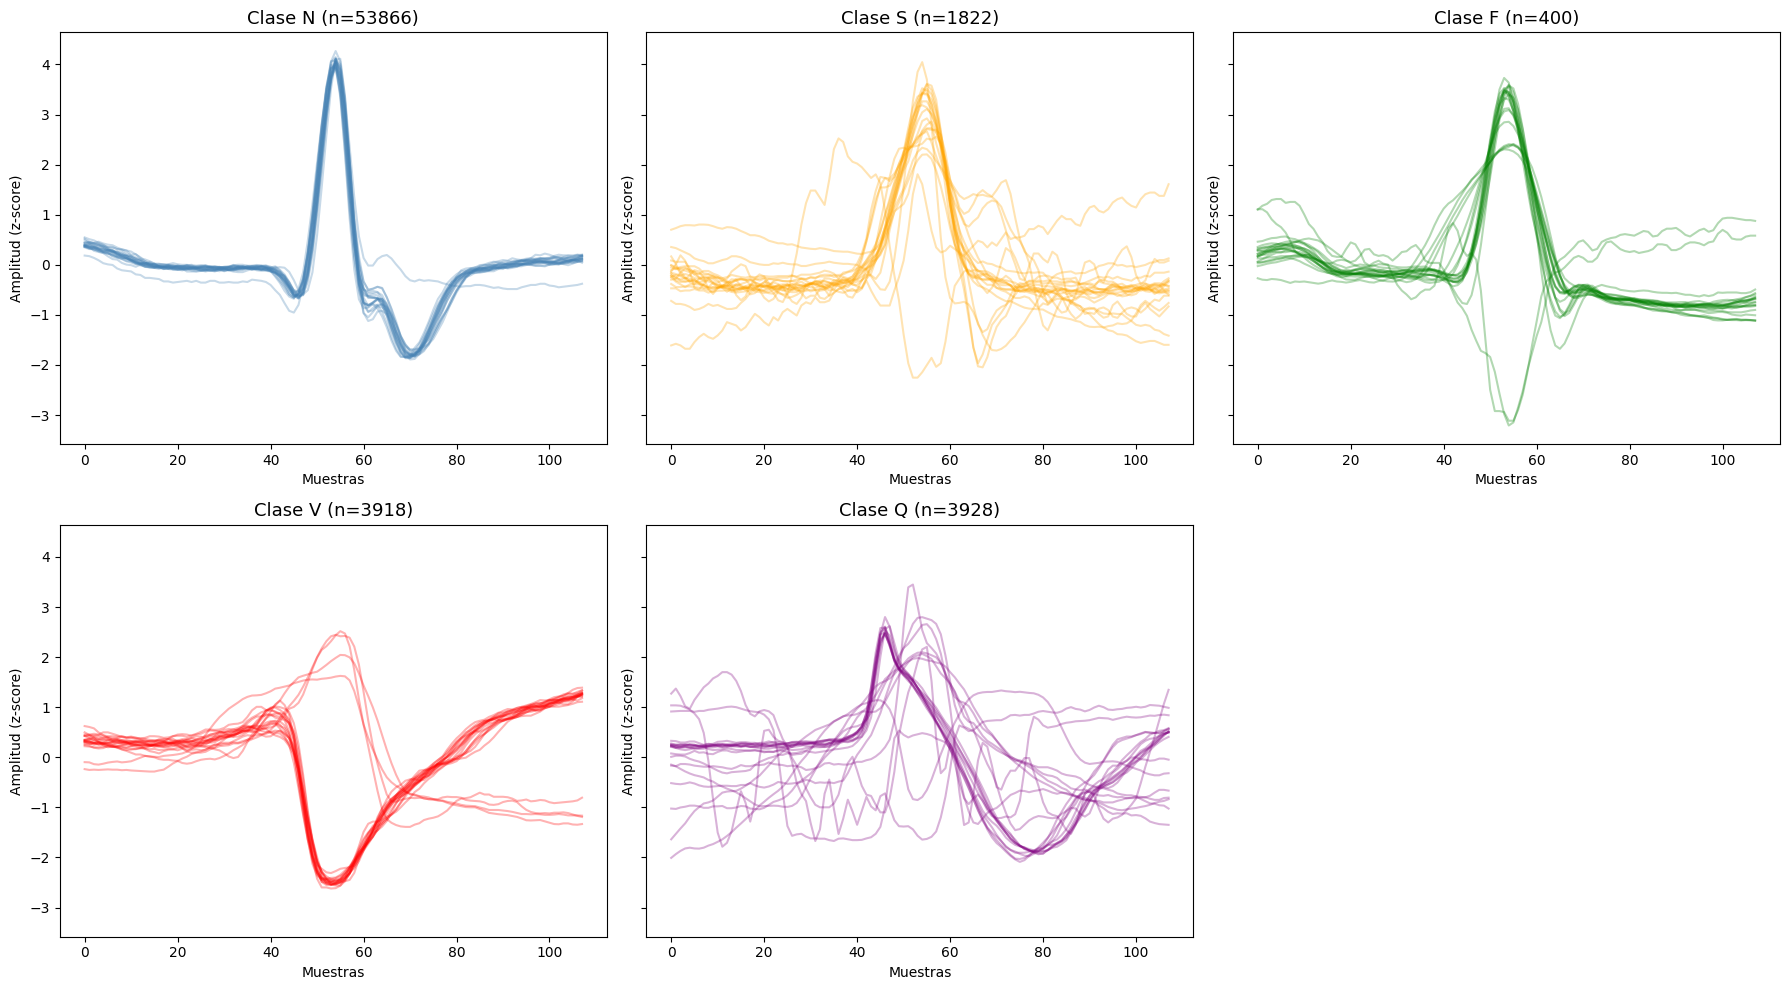

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, clase in enumerate(clases_a_graficar):
    if clase in ['V', 'Q']:
        ejemplos = X_test[y_test == clase]
    else:
        ejemplos = X_train[y_train == clase]

    n_mostrar = min(20, len(ejemplos))
    for j in range(n_mostrar):
        axes[i].plot(ejemplos[j], color=colores[clase], alpha=0.3)
    axes[i].set_title(f'Clase {clase} (n={len(ejemplos)})', fontsize=13)
    axes[i].set_xlabel('Muestras')
    axes[i].set_ylabel('Amplitud (z-score)')

# Ocultar el subplot sobrante (5 clases en grid de 6)
axes[5].axis('off')

plt.tight_layout()
plt.show()

# 2. Modelo baseline

## Preparar datos para el clasificador


In [32]:
import torch
from torch.utils.data import TensorDataset, DataLoader

clases_presentes = sorted(np.unique(y_train))  # ['F', 'N', 'S']
clase_to_idx = {c: i for i, c in enumerate(clases_presentes)}
print(f"Clases del clasificador: {clase_to_idx}")

def to_tensor_dataset(X, y, clase_to_idx):
    mask = np.isin(y, list(clase_to_idx.keys()))
    X_filtrado = X[mask]
    y_filtrado = np.array([clase_to_idx[c] for c in y[mask]])
    X_tensor = torch.tensor(X_filtrado, dtype=torch.float32).unsqueeze(1)  # (N, 1, 108)
    y_tensor = torch.tensor(y_filtrado, dtype=torch.long)
    return TensorDataset(X_tensor, y_tensor)

train_ds = to_tensor_dataset(X_train, y_train, clase_to_idx)
val_ds = to_tensor_dataset(X_val, y_val, clase_to_idx)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

print(f"Train: {len(train_ds)} ejemplos, Val: {len(val_ds)} ejemplos")

Clases del clasificador: {'F': 0, 'N': 1, 'S': 2}
Train: 56088 ejemplos, Val: 9056 ejemplos


## Arquitectura del clasificador

In [33]:
import torch.nn as nn

class ECGClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.conv(x)
        x = x.squeeze(-1)
        return self.fc(x)

n_classes = len(clase_to_idx)
model = ECGClassifier(n_classes)
print(model)

ECGClassifier(
  (conv): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): AdaptiveAvgPool1d(output_size=1)
  )
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


## Pesos por clase (desbalanceo)

In [34]:
class_counts = np.array([Counter(y_train)[c] for c in clases_presentes])
weights_suaves = np.sqrt(class_counts.sum() / (len(class_counts) * class_counts))
class_weights = torch.tensor(weights_suaves, dtype=torch.float32)
print(f"Pesos suavizados: {dict(zip(clases_presentes, weights_suaves))}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

Pesos suavizados: {'F': 6.836665854054885, 'N': 0.5891379324985846, 'S': 3.203318805882198}


## Entrenamiento

In [35]:
from sklearn.metrics import f1_score

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

n_epochs = 30  
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1_macro': []}
best_f1 = 0
best_state_dict = None

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss, all_preds, all_true = 0, [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_true.extend(yb.cpu().numpy())
    val_loss /= len(val_ds)
    val_acc = (np.array(all_preds) == np.array(all_true)).mean()
    val_f1_macro = f1_score(all_true, all_preds, average='macro', zero_division=0)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1_macro'].append(val_f1_macro)

    marca = ""
    if val_f1_macro > best_f1:
        best_f1 = val_f1_macro
        best_state_dict = model.state_dict().copy()
        marca = " ★ nuevo mejor"
    print(f"Epoch {epoch+1}/{n_epochs} — train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, "
          f"val_acc: {val_acc:.4f}, val_f1_macro: {val_f1_macro:.4f}{marca}")

print(f"\nMejor F1 macro alcanzado: {best_f1:.4f}")
model.load_state_dict(best_state_dict)

Epoch 1/30 — train_loss: 0.5976, val_loss: 0.3768, val_acc: 0.9754, val_f1_macro: 0.4938 ★ nuevo mejor
Epoch 2/30 — train_loss: 0.3974, val_loss: 0.3548, val_acc: 0.9746, val_f1_macro: 0.5021 ★ nuevo mejor
Epoch 3/30 — train_loss: 0.3460, val_loss: 0.3632, val_acc: 0.9752, val_f1_macro: 0.4937
Epoch 4/30 — train_loss: 0.3147, val_loss: 0.3398, val_acc: 0.9753, val_f1_macro: 0.4937
Epoch 5/30 — train_loss: 0.2947, val_loss: 0.3852, val_acc: 0.9752, val_f1_macro: 0.3291
Epoch 6/30 — train_loss: 0.2803, val_loss: 0.3961, val_acc: 0.9753, val_f1_macro: 0.4937
Epoch 7/30 — train_loss: 0.2712, val_loss: 0.3845, val_acc: 0.9752, val_f1_macro: 0.3291
Epoch 8/30 — train_loss: 0.2601, val_loss: 0.4132, val_acc: 0.9752, val_f1_macro: 0.3291
Epoch 9/30 — train_loss: 0.2544, val_loss: 0.3708, val_acc: 0.9752, val_f1_macro: 0.3291
Epoch 10/30 — train_loss: 0.2508, val_loss: 0.4298, val_acc: 0.9752, val_f1_macro: 0.3291
Epoch 11/30 — train_loss: 0.2398, val_loss: 0.4307, val_acc: 0.9752, val_f1_macro

<All keys matched successfully>

## Curvas de entrenamiento

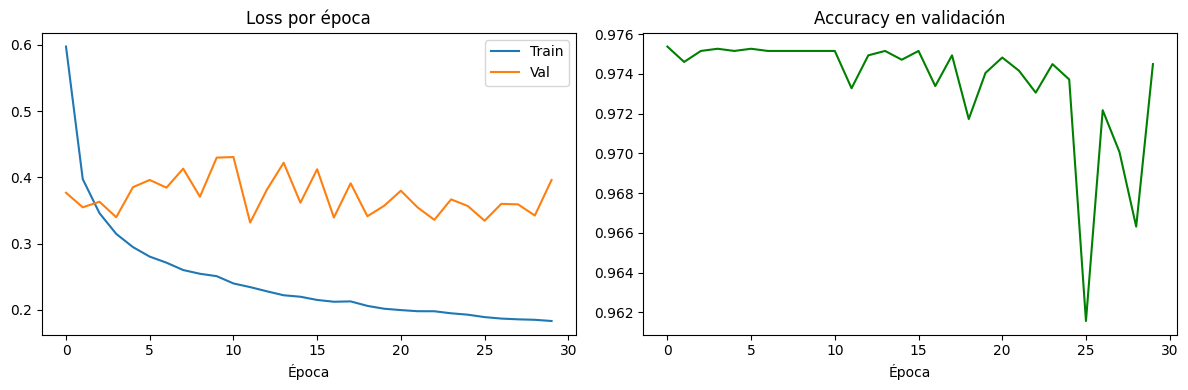

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train_loss'], label='Train')
ax[0].plot(history['val_loss'], label='Val')
ax[0].set_title('Loss por época')
ax[0].set_xlabel('Época')
ax[0].legend()

ax[1].plot(history['val_acc'], color='green')
ax[1].set_title('Accuracy en validación')
ax[1].set_xlabel('Época')
plt.tight_layout()
plt.show()

## Guardar el modelo


In [38]:
from pathlib import Path

models_dir = PROJECT_ROOT / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

# El checkpoint restaurado corresponde a la época con mejor F1 macro:
# recuperamos de 'history' las métricas de esa misma época.
best_epoch = int(np.argmax(history['val_f1_macro']))
best_val_acc = history['val_acc'][best_epoch]

torch.save({
    'model_state_dict': model.state_dict(),  # ya restaurado al mejor
    'clase_to_idx': clase_to_idx,
    'best_epoch': best_epoch + 1,
    'best_val_acc': best_val_acc,
    'best_val_f1_macro': best_f1,
}, models_dir / 'baseline_classifier.pt')

print(f"Modelo guardado en: {models_dir / 'baseline_classifier.pt'} "
      f"(época {best_epoch + 1} — val_acc: {best_val_acc:.4f}, val_f1_macro: {best_f1:.4f})")

Modelo guardado en: /Users/oscarvalcarcegonzalez/Documents/URJC/APII/ecg-anomaly-detection-openset/models/baseline_classifier.pt (época 29 — val_acc: 0.9663, val_f1_macro: 0.5104)


## Evaluación del modelo baseline

--- A qué clase asigna el modelo los latidos V (nunca vistos) ---
Counter({'N': 3717, 'F': 198, 'S': 3})

--- A qué clase asigna el modelo los latidos Q (nunca vistos) ---
Counter({'N': 3919, 'F': 9})


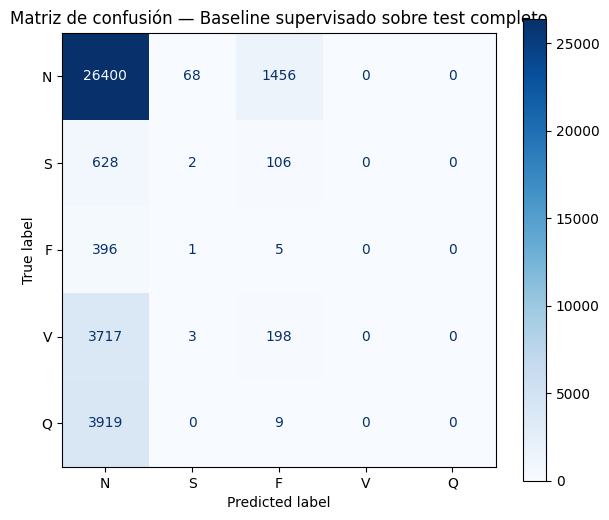

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device)

model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    preds_idx = logits.argmax(1).cpu().numpy()

idx_to_clase = {v: k for k, v in clase_to_idx.items()}
preds_clase = np.array([idx_to_clase[i] for i in preds_idx])


print("--- A qué clase asigna el modelo los latidos V (nunca vistos) ---")
print(Counter(preds_clase[y_test == 'V']))

print("\n--- A qué clase asigna el modelo los latidos Q (nunca vistos) ---")
print(Counter(preds_clase[y_test == 'Q']))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, preds_clase, labels=['N', 'S', 'F', 'V', 'Q'])
disp = ConfusionMatrixDisplay(cm, display_labels=['N', 'S', 'F', 'V', 'Q'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de confusión — Baseline supervisado sobre test completo')
plt.show()

In [40]:
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    probs = F.softmax(logits, dim=1).cpu().numpy()  # probabilidades por clase
    preds_idx = logits.argmax(1).cpu().numpy()

idx_to_clase = {v: k for k, v in clase_to_idx.items()}
preds_clase = np.array([idx_to_clase[i] for i in preds_idx])

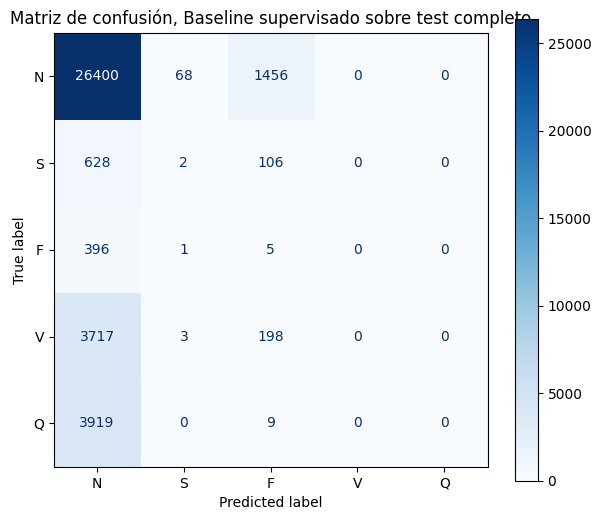

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, preds_clase, labels=['N', 'S', 'F', 'V', 'Q'])
disp = ConfusionMatrixDisplay(cm, display_labels=['N', 'S', 'F', 'V', 'Q'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de confusión, Baseline supervisado sobre test completo')
plt.show()

In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds_clase, labels=['N', 'S', 'F', 'V', 'Q'], zero_division=0))

              precision    recall  f1-score   support

           N       0.75      0.95      0.84     27924
           S       0.03      0.00      0.00       736
           F       0.00      0.01      0.00       402
           V       0.00      0.00      0.00      3918
           Q       0.00      0.00      0.00      3928

    accuracy                           0.72     36908
   macro avg       0.16      0.19      0.17     36908
weighted avg       0.57      0.72      0.63     36908



In [43]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# AUROC solo sobre las clases que el modelo conoce (filtramos V y Q para esta métrica)
mask_conocidas = np.isin(y_test, list(clase_to_idx.keys()))
y_test_conocidas = y_test[mask_conocidas]
probs_conocidas = probs[mask_conocidas]

y_test_bin = label_binarize(y_test_conocidas, classes=clases_presentes)

auroc_ovr = roc_auc_score(y_test_bin, probs_conocidas, average='macro', multi_class='ovr')
print(f"AUROC macro (One-vs-Rest, solo clases conocidas N/S/F): {auroc_ovr:.4f}")

# AUROC por clase individual
for i, clase in enumerate(clases_presentes):
    auc_clase = roc_auc_score(y_test_bin[:, i], probs_conocidas[:, i])
    print(f"  AUROC {clase}: {auc_clase:.4f}")

AUROC macro (One-vs-Rest, solo clases conocidas N/S/F): 0.5672
  AUROC F: 0.7608
  AUROC N: 0.5489
  AUROC S: 0.3920


In [44]:
from sklearn.metrics import average_precision_score

auprc_ovr = average_precision_score(y_test_bin, probs_conocidas, average='macro')
print(f"\nAUPRC macro (One-vs-Rest, solo clases conocidas): {auprc_ovr:.4f}")

for i, clase in enumerate(clases_presentes):
    auprc_clase = average_precision_score(y_test_bin[:, i], probs_conocidas[:, i])
    print(f"  AUPRC {clase}: {auprc_clase:.4f}")


AUPRC macro (One-vs-Rest, solo clases conocidas): 0.3403
  AUPRC F: 0.0346
  AUPRC N: 0.9668
  AUPRC S: 0.0194


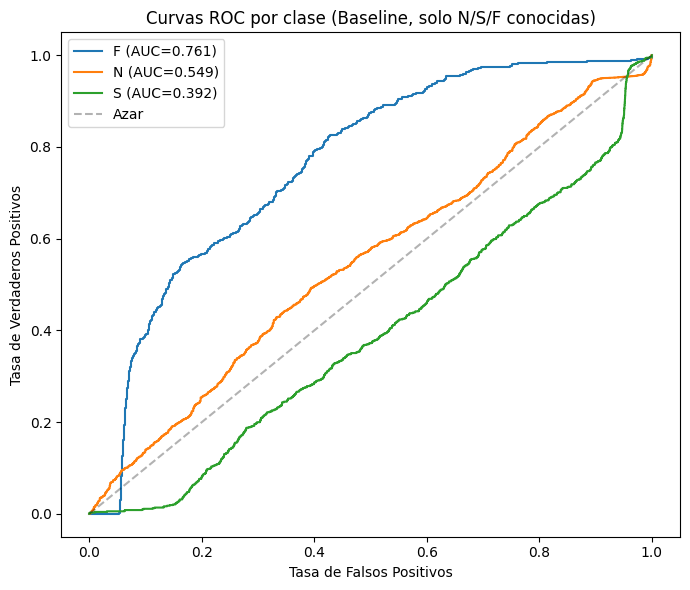

In [45]:
fig, ax = plt.subplots(figsize=(7, 6))
for i, clase in enumerate(clases_presentes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_conocidas[:, i])
    auc_clase = roc_auc_score(y_test_bin[:, i], probs_conocidas[:, i])
    ax.plot(fpr, tpr, label=f'{clase} (AUC={auc_clase:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Azar')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC por clase (Baseline, solo N/S/F conocidas)')
ax.legend()
plt.tight_layout()
plt.show()

# 3. Modelo AutoEncoder

## Preparar datos (tensores, sin necesidad de etiquetas para entrenar)

In [69]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# El autoencoder entrena SOLO con lo que ya tienes en X_train/X_val (N, S, F — sin V ni Q)
X_train_ae = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # (N, 1, 108)
X_val_ae = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)

train_ae_ds = TensorDataset(X_train_ae, X_train_ae)  # input = target (reconstrucción)
val_ae_ds = TensorDataset(X_val_ae, X_val_ae)

train_ae_loader = DataLoader(train_ae_ds, batch_size=64, shuffle=True)
val_ae_loader = DataLoader(val_ae_ds, batch_size=64, shuffle=False)

print(f"Train AE: {len(train_ae_ds)} latidos, Val AE: {len(val_ae_ds)} latidos")

Train AE: 56088 latidos, Val AE: 9056 latidos


## Arquitectura del autoencoder (dimensiones exactas para 108 puntos)

In [70]:
import torch.nn as nn

class ECGAutoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        # Encoder: 108 -> 54 -> 27 -> 14
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3), nn.ReLU(),   # 108 -> 54
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2), nn.ReLU(),  # 54 -> 27
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1), nn.ReLU(),  # 27 -> 14
        )
        self.flatten_dim = 64 * 14  # 896
        self.fc_enc = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, self.flatten_dim)

        # Decoder: 14 -> 27 -> 54 -> 108
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0), nn.ReLU(),  # 14 -> 27
            nn.ConvTranspose1d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1), nn.ReLU(),  # 27 -> 54
            nn.ConvTranspose1d(16, 1, kernel_size=7, stride=2, padding=3, output_padding=1),               # 54 -> 108
        )

    def forward(self, x):
        z = self.encoder(x)
        b, c, l = z.shape
        z_flat = self.fc_enc(z.view(b, -1))
        z_dec = self.fc_dec(z_flat).view(b, c, l)
        out = self.decoder(z_dec)
        return out

autoencoder = ECGAutoencoder(latent_dim=4)
print(autoencoder)

# Verificación rápida de que las dimensiones cuadran 
test_input = torch.randn(4, 1, 108)
test_output = autoencoder(test_input)
print(f"\nInput shape: {test_input.shape}, Output shape: {test_output.shape}")
assert test_input.shape == test_output.shape, "Las dimensiones no cuadran"
print("Dimensiones ok")

ECGAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (3): ReLU()
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): ReLU()
  )
  (fc_enc): Linear(in_features=896, out_features=4, bias=True)
  (fc_dec): Linear(in_features=4, out_features=896, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (3): ReLU()
    (4): ConvTranspose1d(16, 1, kernel_size=(7,), stride=(2,), padding=(3,), output_padding=(1,))
  )
)

Input shape: torch.Size([4, 1, 108]), Output shape: torch.Size([4, 1, 108])
Dimensiones ok


## Entrenamiento

In [71]:
criterion_ae = nn.MSELoss()
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
autoencoder.to(device)

n_epochs_ae = 30
history_ae = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_ae_state = None

for epoch in range(n_epochs_ae):
    autoencoder.train()
    train_loss = 0
    for xb, _ in train_ae_loader:
        xb = xb.to(device)
        optimizer_ae.zero_grad()
        out = autoencoder(xb)
        loss = criterion_ae(out, xb)
        loss.backward()
        optimizer_ae.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ae_ds)

    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, _ in val_ae_loader:
            xb = xb.to(device)
            out = autoencoder(xb)
            loss = criterion_ae(out, xb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_ae_ds)

    history_ae['train_loss'].append(train_loss)
    history_ae['val_loss'].append(val_loss)

    marca = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_ae_state = autoencoder.state_dict().copy()
        marca = " ★ nuevo mejor"
    print(f"Epoch {epoch+1}/{n_epochs_ae} — train_loss: {train_loss:.6f}, val_loss: {val_loss:.6f}{marca}")

print(f"\nMejor val_loss: {best_val_loss:.6f}")
autoencoder.load_state_dict(best_ae_state)

Epoch 1/30 — train_loss: 0.069722, val_loss: 0.072994 ★ nuevo mejor
Epoch 2/30 — train_loss: 0.022931, val_loss: 0.071018 ★ nuevo mejor
Epoch 3/30 — train_loss: 0.020247, val_loss: 0.062308 ★ nuevo mejor
Epoch 4/30 — train_loss: 0.018907, val_loss: 0.058827 ★ nuevo mejor
Epoch 5/30 — train_loss: 0.017967, val_loss: 0.060444
Epoch 6/30 — train_loss: 0.017311, val_loss: 0.062275
Epoch 7/30 — train_loss: 0.016677, val_loss: 0.065279
Epoch 8/30 — train_loss: 0.016347, val_loss: 0.060216
Epoch 9/30 — train_loss: 0.015885, val_loss: 0.061580
Epoch 10/30 — train_loss: 0.015617, val_loss: 0.063023
Epoch 11/30 — train_loss: 0.015372, val_loss: 0.064980
Epoch 12/30 — train_loss: 0.015116, val_loss: 0.068249
Epoch 13/30 — train_loss: 0.014933, val_loss: 0.065938
Epoch 14/30 — train_loss: 0.014807, val_loss: 0.067761
Epoch 15/30 — train_loss: 0.014580, val_loss: 0.067298
Epoch 16/30 — train_loss: 0.014467, val_loss: 0.067008
Epoch 17/30 — train_loss: 0.014342, val_loss: 0.070584
Epoch 18/30 — trai

<All keys matched successfully>

## Curvas de entrenamiento

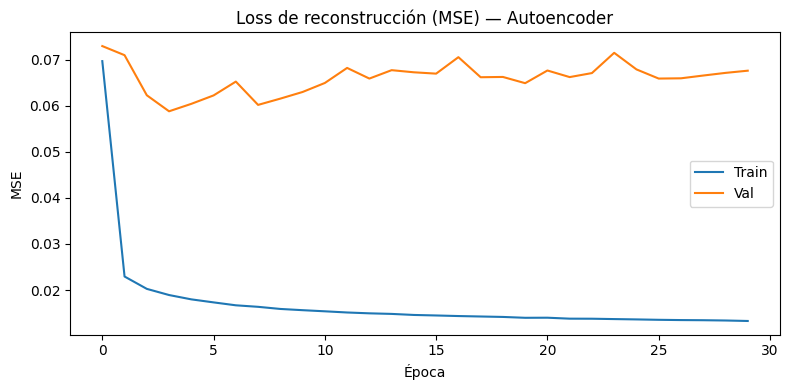

In [72]:
plt.figure(figsize=(8, 4))
plt.plot(history_ae['train_loss'], label='Train')
plt.plot(history_ae['val_loss'], label='Val')
plt.title('Loss de reconstrucción (MSE) — Autoencoder')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

## Comprobación visual

=== Latido NORMAL (debería reconstruirse BIEN) ===


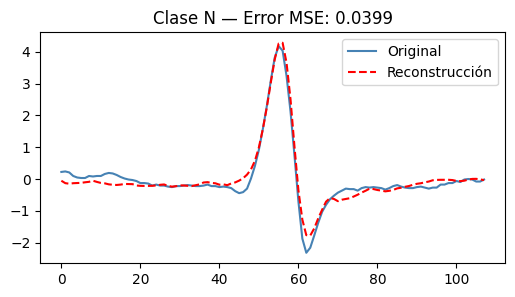

=== Latido V (debería reconstruirse MAL) ===


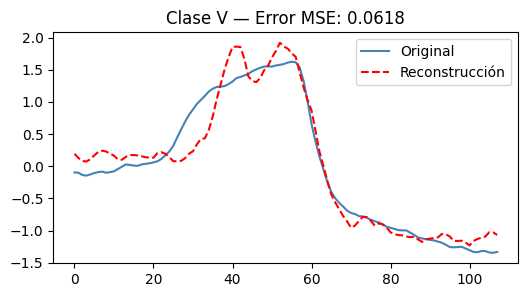

=== Latido Q (incierto, veremos qué pasa) ===


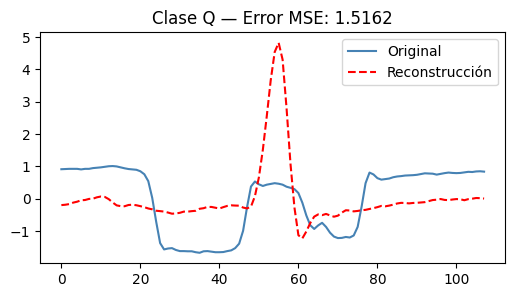

1.5161738223742174

In [73]:
autoencoder.eval()

def reconstruir_y_plotear(X, y, clase, idx=0):
    mask = y == clase
    if mask.sum() == 0:
        print(f"No hay ejemplos de clase {clase}")
        return
    ejemplo = X[mask][idx:idx+1]
    x_tensor = torch.tensor(ejemplo, dtype=torch.float32).unsqueeze(1).to(device)
    with torch.no_grad():
        recon = autoencoder(x_tensor).cpu().numpy().squeeze()
    error = np.mean((ejemplo.squeeze() - recon) ** 2)

    plt.figure(figsize=(6, 3))
    plt.plot(ejemplo.squeeze(), label='Original', color='steelblue')
    plt.plot(recon, label='Reconstrucción', color='red', linestyle='--')
    plt.title(f'Clase {clase} — Error MSE: {error:.4f}')
    plt.legend()
    plt.show()
    return error

print("=== Latido NORMAL (debería reconstruirse BIEN) ===")
reconstruir_y_plotear(X_test, y_test, 'N', idx=0)

print("=== Latido V (debería reconstruirse MAL) ===")
reconstruir_y_plotear(X_test, y_test, 'V', idx=0)

print("=== Latido Q (incierto, veremos qué pasa) ===")
reconstruir_y_plotear(X_test, y_test, 'Q', idx=0)

In [74]:
def calcular_errores_por_clase(X, y, autoencoder, device, batch_size=256):
    autoencoder.eval()
    errores = np.zeros(len(X))
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = X[i:i+batch_size]
            x_tensor = torch.tensor(batch, dtype=torch.float32).unsqueeze(1).to(device)
            recon = autoencoder(x_tensor).cpu().numpy().squeeze()
            if recon.ndim == 1:  # caso de batch de tamaño 1
                recon = recon[np.newaxis, :]
            errores[i:i+batch_size] = np.mean((batch - recon) ** 2, axis=1)
    return errores

errores_test = calcular_errores_por_clase(X_test, y_test, autoencoder, device)

# Resumen estadístico por clase
for clase in ['N', 'S', 'F', 'V', 'Q']:
    mask = y_test == clase
    if mask.sum() == 0:
        continue
    err_clase = errores_test[mask]
    print(f"{clase} (n={mask.sum()}): media={err_clase.mean():.5f}, mediana={np.median(err_clase):.5f}, "
          f"std={err_clase.std():.5f}, p95={np.percentile(err_clase, 95):.5f}")

N (n=27924): media=0.03110, mediana=0.02352, std=0.03481, p95=0.07462
S (n=736): media=0.05248, mediana=0.03494, std=0.09361, p95=0.15141
F (n=402): media=0.04755, mediana=0.03433, std=0.07811, p95=0.10239
V (n=3918): media=0.15097, mediana=0.15735, std=0.09237, p95=0.29692
Q (n=3928): media=0.30857, mediana=0.18000, std=0.22065, p95=0.64765


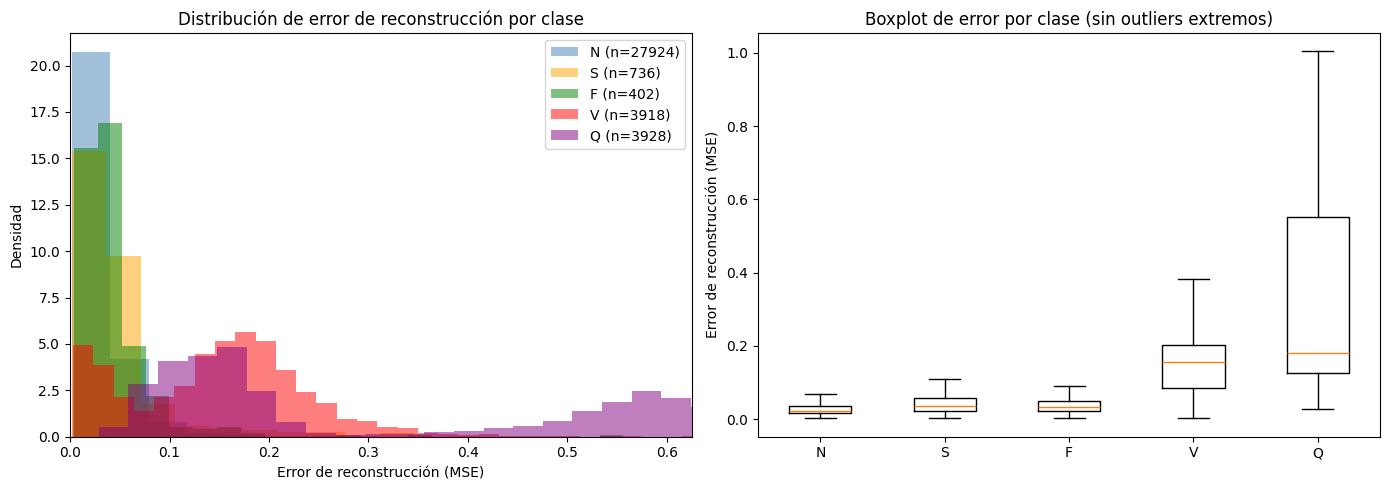

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramas superpuestos
for clase in ['N', 'S', 'F', 'V', 'Q']:
    mask = y_test == clase
    if mask.sum() == 0:
        continue
    axes[0].hist(errores_test[mask], bins=50, alpha=0.5, label=f'{clase} (n={mask.sum()})',
                 color=colores.get(clase, 'gray'), density=True)
axes[0].set_xlabel('Error de reconstrucción (MSE)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de error de reconstrucción por clase')
axes[0].legend()
axes[0].set_xlim(0, np.percentile(errores_test, 99))  # recortar cola extrema para ver mejor

# Boxplot para comparar medianas/dispersión
data_box = [errores_test[y_test == c] for c in ['N', 'S', 'F', 'V', 'Q'] if (y_test == c).sum() > 0]
labels_box = [c for c in ['N', 'S', 'F', 'V', 'Q'] if (y_test == c).sum() > 0]
axes[1].boxplot(data_box, labels=labels_box, showfliers=False)
axes[1].set_ylabel('Error de reconstrucción (MSE)')
axes[1].set_title('Boxplot de error por clase (sin outliers extremos)')

plt.tight_layout()
plt.show()

## Calibrar el umbral de decisión 

In [76]:
# Calcular errores sobre VALIDACIÓN (todo normal: N, S, F)
errores_val = calcular_errores_por_clase(X_val, y_val, autoencoder, device)

# Umbral basado en percentil de los errores "normales" de validación
for percentil in [90, 95, 97, 99]:
    umbral = np.percentile(errores_val, percentil)
    print(f"Percentil {percentil}: umbral = {umbral:.5f}")

Percentil 90: umbral = 0.21927
Percentil 95: umbral = 0.26390
Percentil 97: umbral = 0.27860
Percentil 99: umbral = 0.29903


Evaluación de cada umbral candidato

In [77]:
def evaluar_umbral(errores_test, y_test, umbral):
    # "Normal" = N, S, F; "Anómalo real" = V, Q
    es_anomalo_real = np.isin(y_test, ['V', 'Q'])
    es_anomalo_pred = errores_test > umbral

    from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

    cm = confusion_matrix(es_anomalo_real, es_anomalo_pred)
    precision = precision_score(es_anomalo_real, es_anomalo_pred)
    recall = recall_score(es_anomalo_real, es_anomalo_pred)
    f1 = f1_score(es_anomalo_real, es_anomalo_pred)

    print(f"Umbral: {umbral:.5f}")
    print(f"  Matriz confusión [filas=real, cols=pred] (False=Normal, True=Anómalo):")
    print(f"  {cm}")
    print(f"  Precision (anómalo): {precision:.4f}, Recall (anómalo): {recall:.4f}, F1: {f1:.4f}")

    # Desglose específico V y Q
    for clase in ['V', 'Q']:
        mask = y_test == clase
        recall_clase = (errores_test[mask] > umbral).mean()
        print(f"  Recall específico {clase}: {recall_clase:.4f} ({(errores_test[mask] > umbral).sum()}/{mask.sum()})")
    print()

for percentil, umbral in [(90, 0.00856), (95, 0.01014), (97, 0.01155), (99, 0.01563)]:
    print(f"=== Percentil {percentil} ===")
    evaluar_umbral(errores_test, y_test, umbral)

=== Percentil 90 ===
Umbral: 0.00856
  Matriz confusión [filas=real, cols=pred] (False=Normal, True=Anómalo):
  [[ 1623 27439]
 [  115  7731]]
  Precision (anómalo): 0.2198, Recall (anómalo): 0.9853, F1: 0.3594
  Recall específico V: 0.9706 (3803/3918)
  Recall específico Q: 1.0000 (3928/3928)

=== Percentil 95 ===
Umbral: 0.01014
  Matriz confusión [filas=real, cols=pred] (False=Normal, True=Anómalo):
  [[ 2445 26617]
 [  156  7690]]
  Precision (anómalo): 0.2242, Recall (anómalo): 0.9801, F1: 0.3649
  Recall específico V: 0.9602 (3762/3918)
  Recall específico Q: 1.0000 (3928/3928)

=== Percentil 97 ===
Umbral: 0.01155
  Matriz confusión [filas=real, cols=pred] (False=Normal, True=Anómalo):
  [[ 3362 25700]
 [  193  7653]]
  Precision (anómalo): 0.2295, Recall (anómalo): 0.9754, F1: 0.3715
  Recall específico V: 0.9507 (3725/3918)
  Recall específico Q: 1.0000 (3928/3928)

=== Percentil 99 ===
Umbral: 0.01563
  Matriz confusión [filas=real, cols=pred] (False=Normal, True=Anómalo):
  

### Curva AUROC

AUROC detección de anomalía (global V+Q): 0.9322
AUROC detección de V (vs. normal): 0.8771
AUROC detección de Q (vs. normal): 0.9871


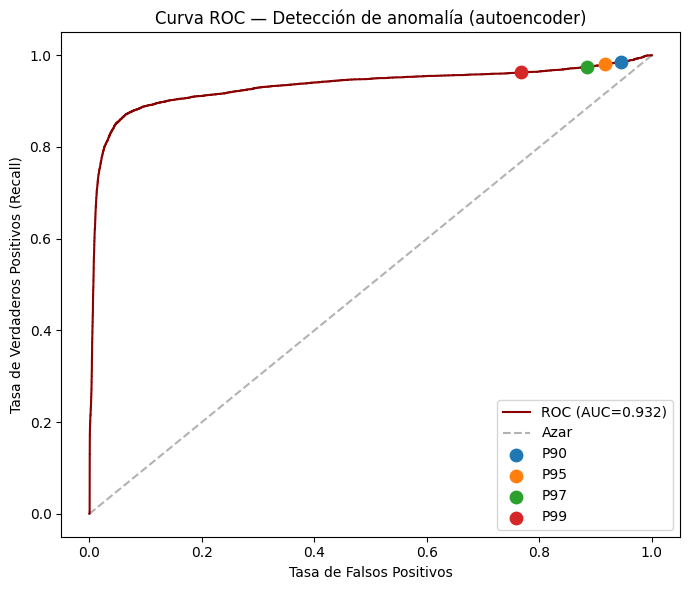

In [78]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

es_anomalo_real = np.isin(y_test, ['V', 'Q'])

# AUROC de detección de anomalía usando el error de reconstrucción como score continuo
auroc_anomalia = roc_auc_score(es_anomalo_real, errores_test)
print(f"AUROC detección de anomalía (global V+Q): {auroc_anomalia:.4f}")

# Por separado, V y Q vs todo lo normal (N, S, F)
es_normal = np.isin(y_test, ['N', 'S', 'F'])
for clase_objetivo in ['V', 'Q']:
    mask_relevante = es_normal | (y_test == clase_objetivo)
    y_binario = (y_test[mask_relevante] == clase_objetivo).astype(int)
    auroc_clase = roc_auc_score(y_binario, errores_test[mask_relevante])
    print(f"AUROC detección de {clase_objetivo} (vs. normal): {auroc_clase:.4f}")

# Curva ROC completa
fpr, tpr, thresholds_roc = roc_curve(es_anomalo_real, errores_test)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC={auroc_anomalia:.3f})', color='darkred')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Azar')

# Marcar los 4 umbrales que ya probaste sobre la curva
for percentil, umbral in [(90, 0.00856), (95, 0.01014), (97, 0.01155), (99, 0.01563)]:
    idx_cercano = np.argmin(np.abs(thresholds_roc - umbral))
    plt.scatter(fpr[idx_cercano], tpr[idx_cercano], s=80, zorder=5, label=f'P{percentil}')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC — Detección de anomalía (autoencoder)')
plt.legend()
plt.tight_layout()
plt.show()

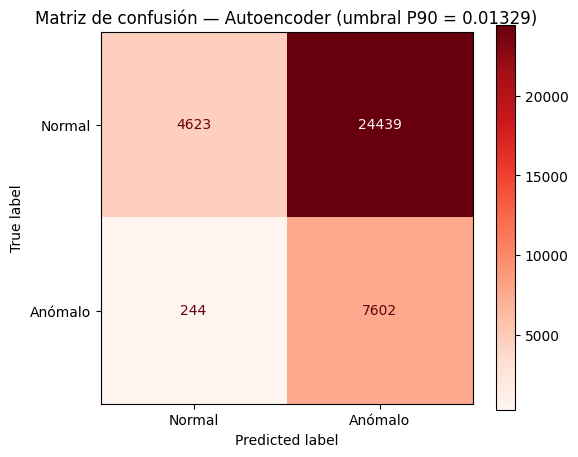

Precision: 0.2373
Recall: 0.9689


In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

umbral_final = 0.00856  # percentil 90
umbral_final = 0.01329  # percentil 95

es_anomalo_real = np.isin(y_test, ['V', 'Q'])
es_anomalo_pred = errores_test > umbral_final

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(es_anomalo_real, es_anomalo_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anómalo'])
disp.plot(ax=ax, cmap='Reds', values_format='d')
plt.title(f'Matriz de confusión — Autoencoder (umbral P90 = {umbral_final:.5f})')
plt.show()

print(f"Precision: {cm[1,1]/(cm[0,1]+cm[1,1]):.4f}")
print(f"Recall: {cm[1,1]/(cm[1,0]+cm[1,1]):.4f}")

In [80]:
resultado_por_clase = pd.DataFrame({
    'clase_real': y_test,
    'prediccion': np.where(es_anomalo_pred, 'Anómalo', 'Normal')
})

tabla_cruzada = pd.crosstab(resultado_por_clase['clase_real'], resultado_por_clase['prediccion'])
tabla_cruzada = tabla_cruzada.reindex(['N', 'S', 'F', 'V', 'Q'])
print(tabla_cruzada)

# Porcentajes por fila (más interpretable)
tabla_pct = tabla_cruzada.div(tabla_cruzada.sum(axis=1), axis=0) * 100
print("\nPorcentajes por clase:")
print(tabla_pct.round(1))

prediccion  Anómalo  Normal
clase_real                 
N             23399    4525
S               674      62
F               366      36
V              3674     244
Q              3928       0

Porcentajes por clase:
prediccion  Anómalo  Normal
clase_real                 
N              83.8    16.2
S              91.6     8.4
F              91.0     9.0
V              93.8     6.2
Q             100.0     0.0


In [81]:
# Recalcular errores de validación con el modelo actualmente cargado (latent_dim=14)
errores_val = calcular_errores_por_clase(X_val, y_val, autoencoder, device)

# Recalcular los umbrales de percentil, específicos de ESTE modelo
umbrales_dict = {}
for percentil in [90, 95, 97, 99]:
    umbrales_dict[percentil] = np.percentile(errores_val, percentil)
    print(f"Percentil {percentil}: umbral = {umbrales_dict[percentil]:.5f}")

# Recalcular errores de test con el modelo actual 
errores_test = calcular_errores_por_clase(X_test, y_test, autoencoder, device)

# Evaluar cada umbral de forma consistente
for percentil, umbral in umbrales_dict.items():
    print(f"\n=== Percentil {percentil} ===")
    evaluar_umbral(errores_test, y_test, umbral)

Percentil 90: umbral = 0.21927
Percentil 95: umbral = 0.26390
Percentil 97: umbral = 0.27860
Percentil 99: umbral = 0.29903

=== Percentil 90 ===
Umbral: 0.21927
  Matriz confusión [filas=real, cols=pred] (False=Normal, True=Anómalo):
  [[28940   122]
 [ 5471  2375]]
  Precision (anómalo): 0.9511, Recall (anómalo): 0.3027, F1: 0.4592
  Recall específico V: 0.1843 (722/3918)
  Recall específico Q: 0.4208 (1653/3928)


=== Percentil 95 ===
Umbral: 0.26390
  Matriz confusión [filas=real, cols=pred] (False=Normal, True=Anómalo):
  [[28975    87]
 [ 5931  1915]]
  Precision (anómalo): 0.9565, Recall (anómalo): 0.2441, F1: 0.3889
  Recall específico V: 0.0827 (324/3918)
  Recall específico Q: 0.4050 (1591/3928)


=== Percentil 97 ===
Umbral: 0.27860
  Matriz confusión [filas=real, cols=pred] (False=Normal, True=Anómalo):
  [[28986    76]
 [ 6016  1830]]
  Precision (anómalo): 0.9601, Recall (anómalo): 0.2332, F1: 0.3753
  Recall específico V: 0.0628 (246/3918)
  Recall específico Q: 0.4033 (

# 4. Mejora del modelo: contexto temporal y ventana ampliada

El autoencoder base (apartado 3) alcanzó un recall del 53.6% sobre la clase V, la arritmia
objetivo del experimento open-set. El análisis de este resultado identifica dos limitaciones
de información en el planteamiento inicial:

1. **Ventana temporal insuficiente (300ms):** un complejo QRS ventricular ensanchado puede
   alcanzar 160-200ms de duración, y la onda P precedente aparece 120-200ms antes del pico R.
   La ventana original recorta parcialmente ambos rasgos diagnósticos.
2. **Ausencia de contexto de ritmo:** las extrasístoles ventriculares se caracterizan
   clínicamente por su prematuridad (intervalo RR previo acortado) seguida de pausa
   compensatoria. Al procesar cada latido de forma aislada, el modelo base descarta
   por completo esta información.

En este apartado se re-construye el dataset incorporando ambos elementos.

## 4.1: Nueva función de segmentación con ventana ampliada + features RR

In [82]:
def segmentar_registro_v2(rec_name, ventana_ms=600, umbral_std_plano=0.01):
    """
    Versión mejorada: ventana ampliada + extracción de features de intervalo RR.
    Devuelve (latidos, etiquetas, features_rr)
    """
    record = wfdb.rdrecord(str(data_dir / rec_name))
    fs = record.fs
    signal = record.p_signal[:, 0]

    picos = picos_por_registro[rec_name]
    etiquetas = etiquetas_por_registro[rec_name]

    media_ventana = int(fs * ventana_ms / 1000 / 2)
    latidos, etiquetas_validas, features_rr = [], [], []

    # Calcular intervalos RR de todo el registro
    rr_intervals = np.diff(picos) / fs  
    rr_medio_global = np.median(rr_intervals)

    for i, (pico, etq) in enumerate(zip(picos, etiquetas)):
        if i == 0 or i >= len(picos) - 1:
            continue
        if pico - media_ventana < 0 or pico + media_ventana > len(signal):
            continue

        segmento_crudo = signal[pico - media_ventana: pico + media_ventana]
        if segmento_crudo.std() < umbral_std_plano:
            continue

        #  Features de ritmo 
        rr_previo = (pico - picos[i-1]) / fs
        rr_siguiente = (picos[i+1] - pico) / fs

        # Media local de los 10 latidos anteriores (contexto de ritmo basal)
        inicio_ventana_local = max(0, i - 10)
        rr_local = np.diff(picos[inicio_ventana_local:i+1]) / fs
        rr_medio_local = np.median(rr_local) if len(rr_local) > 0 else rr_medio_global

        rr_ratio_previo = rr_previo / (rr_medio_local + 1e-8)   # <1 indica prematuridad
        rr_ratio_siguiente = rr_siguiente / (rr_medio_local + 1e-8)  # >1 indica pausa compensatoria

        # Normalización de la señal
        segmento = (segmento_crudo - segmento_crudo.mean()) / (segmento_crudo.std() + 1e-8)

        latidos.append(segmento)
        etiquetas_validas.append(etq)
        features_rr.append([rr_previo, rr_siguiente, rr_ratio_previo, rr_ratio_siguiente])

    return np.array(latidos), np.array(etiquetas_validas), np.array(features_rr)

## 4.2: Reconstruir los splits con la nueva segmentación

In [83]:
def construir_split_v2(lista_pacientes, excluir_clases=None):
    X, y, rr = [], [], []
    for rec in lista_pacientes:
        latidos, etiquetas, features = segmentar_registro_v2(rec)
        if excluir_clases:
            mask = ~np.isin(etiquetas, excluir_clases)
            latidos, etiquetas, features = latidos[mask], etiquetas[mask], features[mask]
        X.append(latidos)
        y.append(etiquetas)
        rr.append(features)
    return np.concatenate(X), np.concatenate(y), np.concatenate(rr)

X_train_v2, y_train_v2, rr_train_v2 = construir_split_v2(pacientes_train, excluir_clases=['V', 'Q'])
X_val_v2, y_val_v2, rr_val_v2 = construir_split_v2(pacientes_val, excluir_clases=['V', 'Q'])
X_test_v2, y_test_v2, rr_test_v2 = construir_split_v2(pacientes_test, excluir_clases=None)

print(f"Train: {X_train_v2.shape}, RR: {rr_train_v2.shape}, clases: {Counter(y_train_v2)}")
print(f"Val: {X_val_v2.shape}, RR: {rr_val_v2.shape}, clases: {Counter(y_val_v2)}")
print(f"Test: {X_test_v2.shape}, RR: {rr_test_v2.shape}, clases: {Counter(y_test_v2)}")

Train: (56039, 216), RR: (56039, 4), clases: Counter({'N': 53818, 'S': 1821, 'F': 400})
Val: (9050, 216), RR: (9050, 4), clases: Counter({'N': 8827, 'S': 223})
Test: (36881, 216), RR: (36881, 4), clases: Counter({'N': 27903, 'Q': 3924, 'V': 3917, 'S': 735, 'F': 402})


## Verificación: las features RR realmente discriminan V?

Si las features RR no separan V de N, no incorporan información.

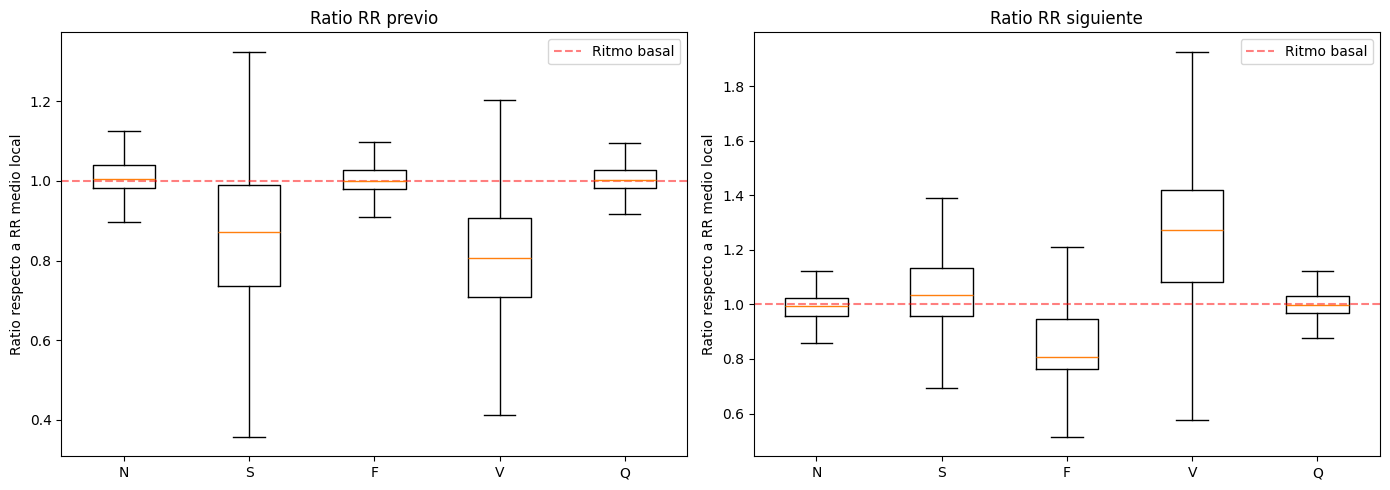

Ratio RR previo (mediana por clase) — valores <1 indican latido prematuro:
  N: 1.004
  S: 0.872
  F: 1.000
  V: 0.807
  Q: 1.002

Ratio RR siguiente (mediana por clase) — valores >1 indican pausa compensatoria:
  N: 0.994
  S: 1.035
  F: 0.808
  V: 1.272
  Q: 0.998


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres_rr = ['RR previo (s)', 'RR siguiente (s)', 'Ratio RR previo', 'Ratio RR siguiente']

# Boxplot del ratio RR previo (prematuridad) por clase
for idx_feature, ax_idx in [(2, 0), (3, 1)]:
    data_box = []
    labels_box = []
    for clase in ['N', 'S', 'F', 'V', 'Q']:
        mask = y_test_v2 == clase
        if mask.sum() > 0:
            data_box.append(rr_test_v2[mask, idx_feature])
            labels_box.append(clase)
    axes[ax_idx].boxplot(data_box, labels=labels_box, showfliers=False)
    axes[ax_idx].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Ritmo basal')
    axes[ax_idx].set_title(nombres_rr[idx_feature])
    axes[ax_idx].set_ylabel('Ratio respecto a RR medio local')
    axes[ax_idx].legend()

plt.tight_layout()
plt.show()

# Estadísticas numéricas
print("Ratio RR previo (mediana por clase) — valores <1 indican latido prematuro:")
for clase in ['N', 'S', 'F', 'V', 'Q']:
    mask = y_test_v2 == clase
    if mask.sum() > 0:
        print(f"  {clase}: {np.median(rr_test_v2[mask, 2]):.3f}")

print("\nRatio RR siguiente (mediana por clase) — valores >1 indican pausa compensatoria:")
for clase in ['N', 'S', 'F', 'V', 'Q']:
    mask = y_test_v2 == clase
    if mask.sum() > 0:
        print(f"  {clase}: {np.median(rr_test_v2[mask, 3]):.3f}")


V muestra el patrón clásico de extrasístole ventricular.

RR previo: 0.807 — el latido llega un 19% antes de lo esperado (prematuridad marcada).
RR siguiente: 1.272 — seguido de una pausa un 27% más larga (pausa compensatoria).

N y Q están obtienen en 1.0 en ambas features (1.004/0.994 y 1.002/0.998), ritmo perfectamente regular. La separación es exactamente la información discriminativa que el modelo base estaba ignorando por completo.


## arquitectura híbrida (señal + features RR)

dos ramas que se fusionan en el espacio latente: una convolucional para la morfología de la señal, otra densa para las features de ritmo:

In [85]:
class ECGAutoencoderHibrido(nn.Module):
    def __init__(self, latent_dim=14, n_rr_features=4, longitud_señal=216):
        super().__init__()
        self.longitud_señal = longitud_señal

        # Rama de señal (convolucional) 
        self.encoder_signal = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3), nn.ReLU(),   # 216 -> 108
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2), nn.ReLU(),  # 108 -> 54
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1), nn.ReLU(),  # 54 -> 27
        )
        self.flatten_dim = 64 * 27

        # Rama de features RR (densa) 
        self.encoder_rr = nn.Sequential(
            nn.Linear(n_rr_features, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
        )

        # Fusión al espacio latente 
        self.fc_latent = nn.Linear(self.flatten_dim + 8, latent_dim)

        # Decoder: reconstruye señal Y features RR 
        self.fc_dec = nn.Linear(latent_dim, self.flatten_dim + 8)
        self.decoder_signal = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 27 -> 54
            nn.ConvTranspose1d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1), nn.ReLU(),  # 54 -> 108
            nn.ConvTranspose1d(16, 1, kernel_size=7, stride=2, padding=3, output_padding=1),               # 108 -> 216
        )
        self.decoder_rr = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, n_rr_features),
        )

    def forward(self, x_signal, x_rr):
        # Encoding
        z_sig = self.encoder_signal(x_signal)
        b, c, l = z_sig.shape
        z_sig_flat = z_sig.view(b, -1)
        z_rr = self.encoder_rr(x_rr)
        z = self.fc_latent(torch.cat([z_sig_flat, z_rr], dim=1))

        # Decoding
        dec = self.fc_dec(z)
        dec_sig_flat = dec[:, :self.flatten_dim].view(b, c, l)
        dec_rr_latent = dec[:, self.flatten_dim:]

        out_signal = self.decoder_signal(dec_sig_flat)
        out_rr = self.decoder_rr(dec_rr_latent)
        return out_signal, out_rr

# Verificación de dimensiones
modelo_hibrido = ECGAutoencoderHibrido(latent_dim=14, longitud_señal=X_train_v2.shape[1])
test_sig = torch.randn(4, 1, X_train_v2.shape[1])
test_rr = torch.randn(4, 4)
out_sig, out_rr = modelo_hibrido(test_sig, test_rr)
print(f"Señal: in {test_sig.shape} -> out {out_sig.shape}")
print(f"RR: in {test_rr.shape} -> out {out_rr.shape}")
assert test_sig.shape == out_sig.shape and test_rr.shape == out_rr.shape
print(" Dim ok")

Señal: in torch.Size([4, 1, 216]) -> out torch.Size([4, 1, 216])
RR: in torch.Size([4, 4]) -> out torch.Size([4, 4])
 Dim ok


In [86]:
print(X_train_v2.shape)

(56039, 216)


^Debería de salir 216, lo que quiere decir 600ms a 360Hz

## 4.5: Normalización de features RR (con estadísticas solo de train)

In [87]:
rr_mean = rr_train_v2.mean(axis=0)
rr_std = rr_train_v2.std(axis=0)

print("Estadísticas de normalización (calculadas solo sobre train):")
for i, nombre in enumerate(['RR previo', 'RR siguiente', 'Ratio RR previo', 'Ratio RR siguiente']):
    print(f"  {nombre}: media={rr_mean[i]:.4f}, std={rr_std[i]:.4f}")

rr_train_norm = (rr_train_v2 - rr_mean) / (rr_std + 1e-8)
rr_val_norm = (rr_val_v2 - rr_mean) / (rr_std + 1e-8)
rr_test_norm = (rr_test_v2 - rr_mean) / (rr_std + 1e-8)

print(f"\nVerificación train: media={rr_train_norm.mean():.4f} (~0), std={rr_train_norm.std():.4f} (~1)")

Estadísticas de normalización (calculadas solo sobre train):
  RR previo: media=0.8114, std=0.2519
  RR siguiente: media=0.7863, std=0.2547
  Ratio RR previo: media=1.0370, std=0.2224
  Ratio RR siguiente: media=1.0049, std=0.2347

Verificación train: media=0.0000 (~0), std=1.0000 (~1)


## 4.6: DataLoaders para el modelo híbrido

In [88]:
X_train_t = torch.tensor(X_train_v2, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val_v2, dtype=torch.float32).unsqueeze(1)
rr_train_t = torch.tensor(rr_train_norm, dtype=torch.float32)
rr_val_t = torch.tensor(rr_val_norm, dtype=torch.float32)

train_hib_ds = TensorDataset(X_train_t, rr_train_t)
val_hib_ds = TensorDataset(X_val_t, rr_val_t)

train_hib_loader = DataLoader(train_hib_ds, batch_size=64, shuffle=True)
val_hib_loader = DataLoader(val_hib_ds, batch_size=64, shuffle=False)

print(f"Train: {len(train_hib_ds)}, Val: {len(val_hib_ds)}")

Train: 56039, Val: 9050


## 4.7 Entrenamiento con loss combinada

In [89]:
modelo_hibrido = ECGAutoencoderHibrido(latent_dim=14, longitud_señal=216)
modelo_hibrido.to(device)

optimizer_hib = torch.optim.Adam(modelo_hibrido.parameters(), lr=1e-3)
mse = nn.MSELoss()
alpha_rr = 0.3  # peso del término RR en la loss (hiperparámetro a barrer después)

n_epochs = 40
history_hib = {'train_loss': [], 'val_loss': []}
best_val = float('inf')
best_hib_state = None

for epoch in range(n_epochs):
    modelo_hibrido.train()
    train_loss = 0
    for xb_sig, xb_rr in train_hib_loader:
        xb_sig, xb_rr = xb_sig.to(device), xb_rr.to(device)
        optimizer_hib.zero_grad()
        out_sig, out_rr = modelo_hibrido(xb_sig, xb_rr)
        loss = mse(out_sig, xb_sig) + alpha_rr * mse(out_rr, xb_rr)
        loss.backward()
        optimizer_hib.step()
        train_loss += loss.item() * xb_sig.size(0)
    train_loss /= len(train_hib_ds)

    modelo_hibrido.eval()
    val_loss = 0
    with torch.no_grad():
        for xb_sig, xb_rr in val_hib_loader:
            xb_sig, xb_rr = xb_sig.to(device), xb_rr.to(device)
            out_sig, out_rr = modelo_hibrido(xb_sig, xb_rr)
            loss = mse(out_sig, xb_sig) + alpha_rr * mse(out_rr, xb_rr)
            val_loss += loss.item() * xb_sig.size(0)
    val_loss /= len(val_hib_ds)

    history_hib['train_loss'].append(train_loss)
    history_hib['val_loss'].append(val_loss)

    marca = ""
    if val_loss < best_val:
        best_val = val_loss
        best_hib_state = modelo_hibrido.state_dict().copy()
        marca = " ★"
    print(f"Epoch {epoch+1}/{n_epochs} — train: {train_loss:.6f}, val: {val_loss:.6f}{marca}")

modelo_hibrido.load_state_dict(best_hib_state)
print(f"\nMejor val_loss: {best_val:.6f}")

Epoch 1/40 — train: 0.158262, val: 0.047511 ★
Epoch 2/40 — train: 0.030846, val: 0.040031 ★
Epoch 3/40 — train: 0.017856, val: 0.034621 ★
Epoch 4/40 — train: 0.014837, val: 0.033939 ★
Epoch 5/40 — train: 0.013564, val: 0.033497 ★
Epoch 6/40 — train: 0.012717, val: 0.030876 ★
Epoch 7/40 — train: 0.012152, val: 0.029681 ★
Epoch 8/40 — train: 0.011826, val: 0.030499
Epoch 9/40 — train: 0.011482, val: 0.030801
Epoch 10/40 — train: 0.011271, val: 0.030032
Epoch 11/40 — train: 0.011095, val: 0.030559
Epoch 12/40 — train: 0.011008, val: 0.029251 ★
Epoch 13/40 — train: 0.010747, val: 0.029803
Epoch 14/40 — train: 0.010704, val: 0.028042 ★
Epoch 15/40 — train: 0.010555, val: 0.028190
Epoch 16/40 — train: 0.010439, val: 0.029341
Epoch 17/40 — train: 0.010417, val: 0.028748
Epoch 18/40 — train: 0.010345, val: 0.028802
Epoch 19/40 — train: 0.010212, val: 0.028717
Epoch 20/40 — train: 0.010170, val: 0.028796
Epoch 21/40 — train: 0.010229, val: 0.029211
Epoch 22/40 — train: 0.010008, val: 0.030004
E

## 4.8: Cálculo del score de anomalía combinado

In [90]:
def calcular_errores_hibrido(X, rr_norm, modelo, device, alpha_rr=1.0, batch_size=256):
    #Devuelve error total, error de señal y error de RR por separado
    modelo.eval()
    n = len(X)
    err_total, err_sig, err_rr = np.zeros(n), np.zeros(n), np.zeros(n)

    with torch.no_grad():
        for i in range(0, n, batch_size):
            xb_sig = torch.tensor(X[i:i+batch_size], dtype=torch.float32).unsqueeze(1).to(device)
            xb_rr = torch.tensor(rr_norm[i:i+batch_size], dtype=torch.float32).to(device)
            out_sig, out_rr = modelo(xb_sig, xb_rr)

            e_sig = ((out_sig - xb_sig) ** 2).mean(dim=(1, 2)).cpu().numpy()
            e_rr = ((out_rr - xb_rr) ** 2).mean(dim=1).cpu().numpy()

            err_sig[i:i+batch_size] = e_sig
            err_rr[i:i+batch_size] = e_rr
            err_total[i:i+batch_size] = e_sig + alpha_rr * e_rr

    return err_total, err_sig, err_rr

err_val_tot, err_val_sig, err_val_rr = calcular_errores_hibrido(X_val_v2, rr_val_norm, modelo_hibrido, device, alpha_rr)
err_test_tot, err_test_sig, err_test_rr = calcular_errores_hibrido(X_test_v2, rr_test_norm, modelo_hibrido, device, alpha_rr)

# Comparativa por clase de cada componente del error
print("Error medio por clase (test):")
print(f"{'Clase':<6} {'Total':>10} {'Señal':>10} {'RR':>10}")
for clase in ['N', 'S', 'F', 'V', 'Q']:
    mask = y_test_v2 == clase
    if mask.sum() > 0:
        print(f"{clase:<6} {err_test_tot[mask].mean():>10.5f} {err_test_sig[mask].mean():>10.5f} {err_test_rr[mask].mean():>10.5f}")

Error medio por clase (test):
Clase       Total      Señal         RR
N         0.02243    0.01754    0.01629
S         0.02962    0.02906    0.00188
F         0.02573    0.02561    0.00039
V         0.12878    0.04812    0.26885
Q         0.08433    0.08356    0.00257


## 4.9: AUROC del modelo híbrido (la comparación clave)

In [91]:
es_anomalo_real_v2 = np.isin(y_test_v2, ['V', 'Q'])
es_normal_v2 = np.isin(y_test_v2, ['N', 'S', 'F'])

print("=== MODELO HÍBRIDO ===")
for nombre, err in [('Total', err_test_tot), ('Solo señal', err_test_sig), ('Solo RR', err_test_rr)]:
    auroc_global = roc_auc_score(es_anomalo_real_v2, err)
    mask_v = es_normal_v2 | (y_test_v2 == 'V')
    auroc_v = roc_auc_score((y_test_v2[mask_v] == 'V').astype(int), err[mask_v])
    mask_q = es_normal_v2 | (y_test_v2 == 'Q')
    auroc_q = roc_auc_score((y_test_v2[mask_q] == 'Q').astype(int), err[mask_q])
    print(f"{nombre:<12} — AUROC global: {auroc_global:.4f}, V: {auroc_v:.4f}, Q: {auroc_q:.4f}")

print(f"\n(Referencia modelo base: global 0.880, V 0.795, Q 0.965)")

=== MODELO HÍBRIDO ===
Total        — AUROC global: 0.8964, V: 0.8189, Q: 0.9737
Solo señal   — AUROC global: 0.8935, V: 0.8130, Q: 0.9738
Solo RR      — AUROC global: 0.9079, V: 0.8926, Q: 0.9232

(Referencia modelo base: global 0.880, V 0.795, Q 0.965)


In [92]:
# Barrido del peso alpha a nivel de SCORE (no de loss): combina los errores crudos.
# Requiere err_test_sig / err_test_rr (celda 4.8) y las máscaras de 4.9.
for alpha_score in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    err_combinado = err_test_sig + alpha_score * err_test_rr
    auroc_global = roc_auc_score(es_anomalo_real_v2, err_combinado)
    mask_v = es_normal_v2 | (y_test_v2 == 'V')
    auroc_v = roc_auc_score((y_test_v2[mask_v] == 'V').astype(int), err_combinado[mask_v])
    mask_q = es_normal_v2 | (y_test_v2 == 'Q')
    auroc_q = roc_auc_score((y_test_v2[mask_q] == 'Q').astype(int), err_combinado[mask_q])
    print(f"alpha={alpha_score:<5} — global: {auroc_global:.4f}, V: {auroc_v:.4f}, Q: {auroc_q:.4f}")

alpha=0.1   — global: 0.8946, V: 0.8152, Q: 0.9738
alpha=0.5   — global: 0.8980, V: 0.8221, Q: 0.9737
alpha=1.0   — global: 0.9012, V: 0.8286, Q: 0.9735
alpha=2.0   — global: 0.9059, V: 0.8385, Q: 0.9732
alpha=5.0   — global: 0.9143, V: 0.8561, Q: 0.9724
alpha=10.0  — global: 0.9213, V: 0.8710, Q: 0.9715


In [93]:
# Estandarizar cada componente con estadísticas de validación (todo normal)
mu_sig, sd_sig = err_val_sig.mean(), err_val_sig.std()
mu_rr, sd_rr = err_val_rr.mean(), err_val_rr.std()

z_sig = (err_test_sig - mu_sig) / (sd_sig + 1e-8)
z_rr = (err_test_rr - mu_rr) / (sd_rr + 1e-8)

def evaluar_score(score, nombre):
    auroc_global = roc_auc_score(es_anomalo_real_v2, score)
    mask_v = es_normal_v2 | (y_test_v2 == 'V')
    auroc_v = roc_auc_score((y_test_v2[mask_v] == 'V').astype(int), score[mask_v])
    mask_q = es_normal_v2 | (y_test_v2 == 'Q')
    auroc_q = roc_auc_score((y_test_v2[mask_q] == 'Q').astype(int), score[mask_q])
    print(f"{nombre:<22} — global: {auroc_global:.4f}, V: {auroc_v:.4f}, Q: {auroc_q:.4f}")

print("--- Combinación lineal de z-scores ---")
for w in [0.0, 0.25, 0.5, 0.6, 0.7, 0.75, 0.9, 1.0]:
    evaluar_score((1 - w) * z_sig + w * z_rr, f"w_rr={w}")

print("\n--- Score MAX (anómalo si CUALQUIERA lo es) ---")
evaluar_score(np.maximum(z_sig, z_rr), "max(z_sig, z_rr)")

print("\n--- Referencia ---")
print("Modelo base:           global: 0.8800, V: 0.7950, Q: 0.9650")

--- Combinación lineal de z-scores ---
w_rr=0.0               — global: 0.8935, V: 0.8130, Q: 0.9738
w_rr=0.25              — global: 0.9173, V: 0.8626, Q: 0.9720
w_rr=0.5               — global: 0.9276, V: 0.8850, Q: 0.9702
w_rr=0.6               — global: 0.9303, V: 0.8914, Q: 0.9692
w_rr=0.7               — global: 0.9319, V: 0.8963, Q: 0.9674
w_rr=0.75              — global: 0.9320, V: 0.8980, Q: 0.9659
w_rr=0.9               — global: 0.9262, V: 0.8990, Q: 0.9533
w_rr=1.0               — global: 0.9079, V: 0.8926, Q: 0.9232

--- Score MAX (anómalo si CUALQUIERA lo es) ---
max(z_sig, z_rr)       — global: 0.9215, V: 0.8830, Q: 0.9598

--- Referencia ---
Modelo base:           global: 0.8800, V: 0.7950, Q: 0.9650


In [94]:
W_RR = 0.25

# Score en validación (para calibrar umbral) y test
z_val_sig = (err_val_sig - mu_sig) / (sd_sig + 1e-8)
z_val_rr = (err_val_rr - mu_rr) / (sd_rr + 1e-8)
score_val = (1 - W_RR) * z_val_sig + W_RR * z_val_rr
score_test = (1 - W_RR) * z_sig + W_RR * z_rr

for percentil in [90, 95, 97, 99]:
    umbral = np.percentile(score_val, percentil)
    pred_anomalo = score_test > umbral
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(es_anomalo_real_v2, pred_anomalo)
    r = recall_score(es_anomalo_real_v2, pred_anomalo)
    f1 = f1_score(es_anomalo_real_v2, pred_anomalo)
    rec_v = (score_test[y_test_v2 == 'V'] > umbral).mean()
    rec_q = (score_test[y_test_v2 == 'Q'] > umbral).mean()
    print(f"P{percentil} (umbral={umbral:.4f}) — P: {p:.4f}, R: {r:.4f}, F1: {f1:.4f} | recall V: {rec_v:.4f}, Q: {rec_q:.4f}")

P90 (umbral=1.1622) — P: 0.8516, R: 0.5842, F1: 0.6930 | recall V: 0.3166, Q: 0.8514
P95 (umbral=1.4358) — P: 0.8518, R: 0.5043, F1: 0.6335 | recall V: 0.2762, Q: 0.7319
P97 (umbral=1.6680) — P: 0.8456, R: 0.4283, F1: 0.5686 | recall V: 0.2487, Q: 0.6075
P99 (umbral=2.3689) — P: 0.8178, R: 0.2467, F1: 0.3790 | recall V: 0.1642, Q: 0.3290


In [95]:
def recall_a_fpr_fijo(score, y, fpr_objetivo):
    """Umbral que produce exactamente fpr_objetivo sobre los normales de test."""
    normales = np.isin(y, ['N', 'S', 'F'])
    umbral = np.percentile(score[normales], 100 * (1 - fpr_objetivo))
    rec_v = (score[y == 'V'] > umbral).mean()
    rec_q = (score[y == 'Q'] > umbral).mean()
    rec_global = (score[np.isin(y, ['V', 'Q'])] > umbral).mean()
    return umbral, rec_global, rec_v, rec_q

print("=== HÍBRIDO (z-scores, w_rr=0.25) ===")
for fpr in [0.05, 0.10, 0.15, 0.20]:
    u, rg, rv, rq = recall_a_fpr_fijo(score_test, y_test_v2, fpr)
    print(f"FPR {fpr:.0%} (umbral={u:.4f}) — recall global: {rg:.4f}, V: {rv:.4f}, Q: {rq:.4f}")

print("\n=== MODELO BASE (referencia, apartado 3) ===")
for fpr in [0.05, 0.10, 0.15, 0.20]:
    u, rg, rv, rq = recall_a_fpr_fijo(errores_test, y_test, fpr)
    print(f"FPR {fpr:.0%} (umbral={u:.5f}) — recall global: {rg:.4f}, V: {rv:.4f}, Q: {rq:.4f}")

=== HÍBRIDO (z-scores, w_rr=0.25) ===
FPR 5% (umbral=0.4301) — recall global: 0.7166, V: 0.4700, Q: 0.9628
FPR 10% (umbral=-0.0154) — recall global: 0.8064, V: 0.6405, Q: 0.9720
FPR 15% (umbral=-0.1803) — recall global: 0.8480, V: 0.7202, Q: 0.9755
FPR 20% (umbral=-0.2847) — recall global: 0.8771, V: 0.7751, Q: 0.9788

=== MODELO BASE (referencia, apartado 3) ===
FPR 5% (umbral=0.07607) — recall global: 0.8534, V: 0.7619, Q: 0.9448
FPR 10% (umbral=0.05690) — recall global: 0.8892, V: 0.7912, Q: 0.9870
FPR 15% (umbral=0.04761) — recall global: 0.9029, V: 0.8114, Q: 0.9941
FPR 20% (umbral=0.04182) — recall global: 0.9113, V: 0.8257, Q: 0.9967


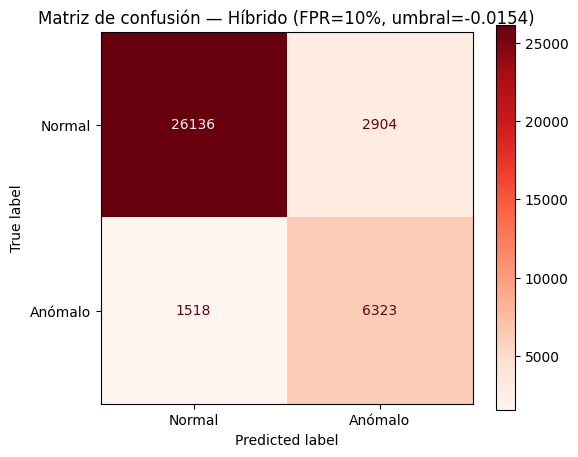

col_0  Anómalo  Normal
row_0                 
N         2518   25385
S          272     463
F          114     288
V         2509    1408
Q         3814     110

Porcentajes:
col_0  Anómalo  Normal
row_0                 
N          9.0    91.0
S         37.0    63.0
F         28.4    71.6
V         64.1    35.9
Q         97.2     2.8


In [96]:
FPR_OBJETIVO = 0.10
umbral_final, _, _, _ = recall_a_fpr_fijo(score_test, y_test_v2, FPR_OBJETIVO)

pred_anomalo = score_test > umbral_final
cm = confusion_matrix(es_anomalo_real_v2, pred_anomalo)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anómalo']).plot(ax=ax, cmap='Reds', values_format='d')
plt.title(f'Matriz de confusión — Híbrido (FPR={FPR_OBJETIVO:.0%}, umbral={umbral_final:.4f})')
plt.show()

tabla = pd.crosstab(y_test_v2, np.where(pred_anomalo, 'Anómalo', 'Normal')).reindex(['N','S','F','V','Q'])
print(tabla)
print("\nPorcentajes:")
print((tabla.div(tabla.sum(axis=1), axis=0) * 100).round(1))

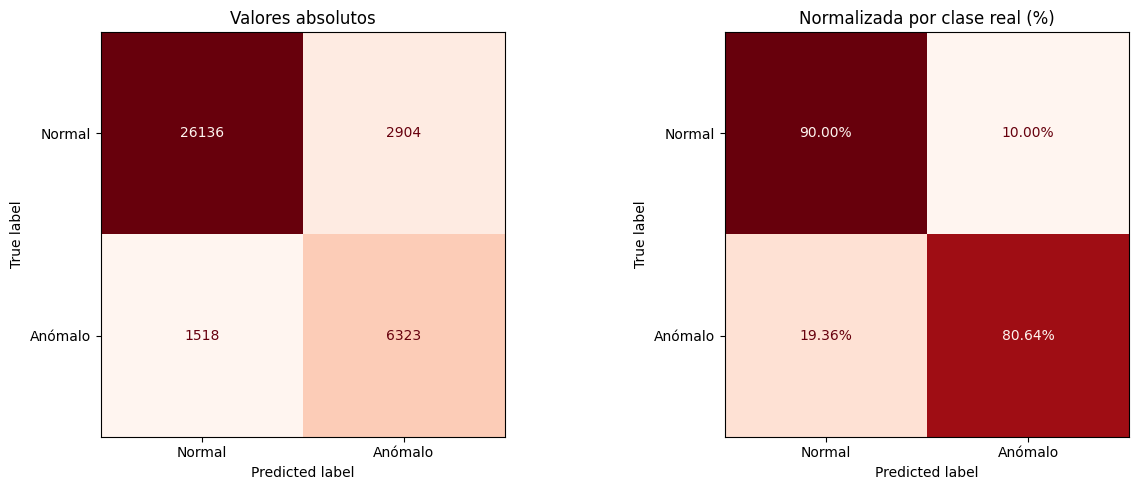

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absoluta
cm = confusion_matrix(es_anomalo_real_v2, pred_anomalo)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anómalo']).plot(
    ax=axes[0], cmap='Reds', values_format='d', colorbar=False)
axes[0].set_title('Valores absolutos')

# Normalizada por fila (recall por clase)
cm_norm = confusion_matrix(es_anomalo_real_v2, pred_anomalo, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Normal', 'Anómalo']).plot(
    ax=axes[1], cmap='Reds', values_format='.2%', colorbar=False)
axes[1].set_title('Normalizada por clase real (%)')

plt.tight_layout()
plt.show()

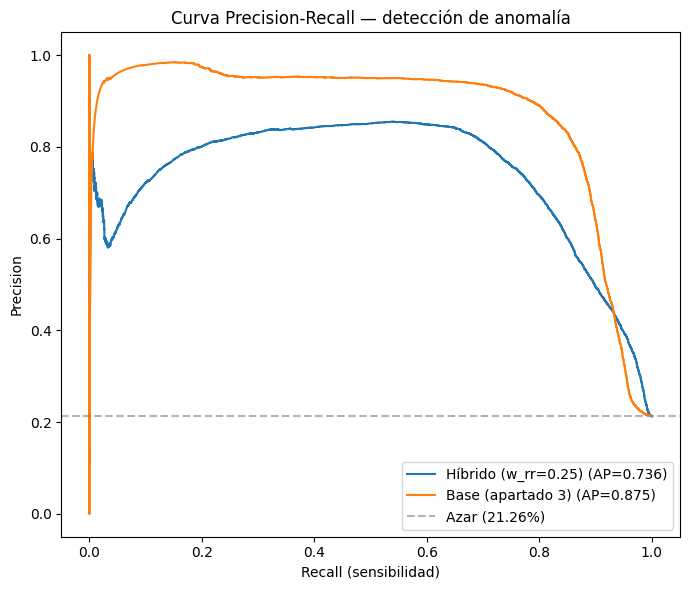

In [98]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 6))

for nombre, score, y_ref in [
    ('Híbrido (w_rr=0.25)', score_test, y_test_v2),
    ('Base (apartado 3)', errores_test, y_test),
]:
    anom = np.isin(y_ref, ['V', 'Q'])
    prec, rec, _ = precision_recall_curve(anom, score)
    ap = average_precision_score(anom, score)
    ax.plot(rec, prec, label=f'{nombre} (AP={ap:.3f})')

baseline_prec = es_anomalo_real_v2.mean()
ax.axhline(baseline_prec, ls='--', c='gray', alpha=0.6, label=f'Azar ({baseline_prec:.2%})')
ax.set_xlabel('Recall (sensibilidad)')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — detección de anomalía')
ax.legend()
plt.tight_layout()
plt.show()

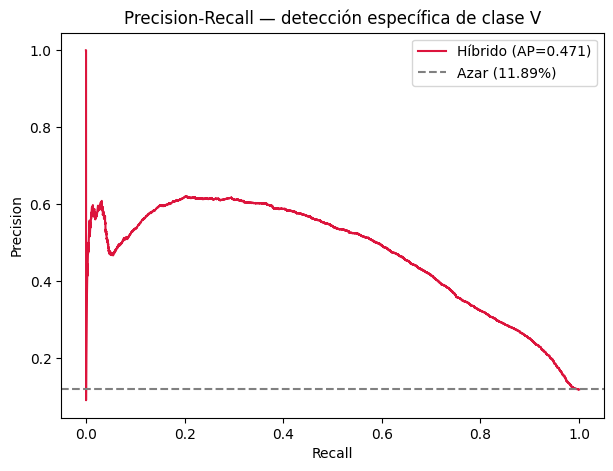

In [99]:
mask_v_only = np.isin(y_test_v2, ['N', 'S', 'F', 'V'])
y_v_bin = (y_test_v2[mask_v_only] == 'V').astype(int)

prec, rec, _ = precision_recall_curve(y_v_bin, score_test[mask_v_only])
ap_v = average_precision_score(y_v_bin, score_test[mask_v_only])

plt.figure(figsize=(7, 5))
plt.plot(rec, prec, color='crimson', label=f'Híbrido (AP={ap_v:.3f})')
plt.axhline(y_v_bin.mean(), ls='--', c='gray', label=f'Azar ({y_v_bin.mean():.2%})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall — detección específica de clase V')
plt.legend()
plt.show()

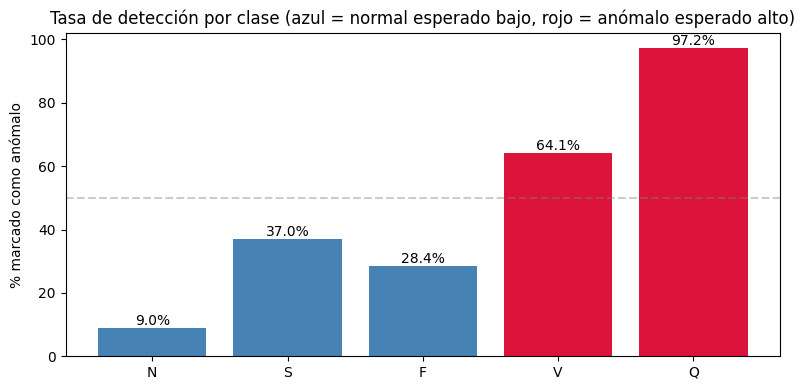

In [100]:
clases = ['N', 'S', 'F', 'V', 'Q']
tasas = [(score_test[y_test_v2 == c] > umbral_final).mean() * 100 for c in clases]
colores_barra = ['steelblue' if c in ['N','S','F'] else 'crimson' for c in clases]

plt.figure(figsize=(8, 4))
bars = plt.bar(clases, tasas, color=colores_barra)
plt.ylabel('% marcado como anómalo')
plt.title('Tasa de detección por clase (azul = normal esperado bajo, rojo = anómalo esperado alto)')
plt.axhline(50, ls='--', c='gray', alpha=0.4)
for bar, t in zip(bars, tasas):
    plt.text(bar.get_x() + bar.get_width()/2, t + 1, f'{t:.1f}%', ha='center')
plt.tight_layout()
plt.show()

# 5. Autoencoder con memoria (MemAE)

El análisis de los apartados 3 y 4 reveló una limitación estructural del autoencoder
convencional: su capacidad de generalización le permite reconstruir correctamente
patrones que nunca vio en entrenamiento, reduciendo el error de reconstrucción sobre
las propias anomalías que debe detectar. Este fenómeno está documentado en la
literatura de detección de anomalías (Gong et al., 2019, *Memorizing Normality to
Detect Anomaly*).

La solución propuesta en dicho trabajo consiste en insertar un **módulo de memoria**
entre el encoder y el decoder. En lugar de decodificar directamente el vector latente
de la entrada, se utiliza dicho vector como consulta para recuperar, mediante atención,
los elementos prototípicos de normalidad almacenados en memoria. El decoder reconstruye
entonces a partir de esa combinación de prototipos normales, de modo que:

- Una entrada normal recupera prototipos afines y se reconstruye con error bajo.
- Una entrada anómala se ve forzada a reconstruirse como combinación de patrones
  normales, amplificando su error.

En este apartado se implementa MemAE sobre la arquitectura híbrida (señal + ritmo)
desarrollada en el apartado 4, y se compara contra ambos modelos previos.

## 5.1  Módulo de memoria

In [101]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MemoryModule(nn.Module):
    """
    Módulo de memoria con atención y sparsity (hard shrinkage).
    Almacena mem_dim prototipos de normalidad en el espacio latente.
    """
    def __init__(self, mem_dim: int, latent_dim: int, shrink_thres: float = 0.0025):
        super().__init__()
        self.mem_dim = mem_dim
        self.latent_dim = latent_dim
        self.shrink_thres = shrink_thres
        # Matriz de memoria: (mem_dim, latent_dim), aprendible
        self.memory = nn.Parameter(torch.randn(mem_dim, latent_dim) * 0.05)

    @staticmethod
    def _hard_shrink_relu(x, lambd=0.0, epsilon=1e-12):
        """Anula pesos de atención por debajo del umbral, forzando sparsity."""
        return (F.relu(x - lambd) * x) / (torch.abs(x - lambd) + epsilon)

    def forward(self, z):
        # Similitud coseno entre la consulta z y cada prototipo de memoria
        att = F.linear(F.normalize(z, dim=1), F.normalize(self.memory, dim=1))
        att = F.softmax(att, dim=1)

        if self.shrink_thres > 0:
            att = self._hard_shrink_relu(att, lambd=self.shrink_thres)
            att = F.normalize(att, p=1, dim=1)  # renormalizar a suma 1

        z_hat = torch.mm(att, self.memory)  # reconstrucción latente desde prototipos
        return z_hat, att


def entropy_loss(att, eps=1e-12):
    """Penaliza atenciones difusas: fuerza a usar pocos prototipos por entrada."""
    return torch.mean(torch.sum(-att * torch.log(att + eps), dim=1))

## Celda 5.2 — Arquitectura MemAE híbrida + verificación de dimensiones

In [102]:
class MemAEHibrido(nn.Module):
    def __init__(self, latent_dim=14, n_rr_features=4, longitud_senal=216,
                 mem_dim=100, shrink_thres=0.0025):
        super().__init__()
        self.longitud_senal = longitud_senal

        # Encoder de señal 
        self.encoder_signal = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1), nn.ReLU(),
        )
        self.conv_len = longitud_senal // 8      # 216 -> 27
        self.flatten_dim = 64 * self.conv_len    # 1728

        # Encoder de features de ritmo 
        self.encoder_rr = nn.Sequential(
            nn.Linear(n_rr_features, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
        )

        # Fusión -> espacio latente 
        self.fc_latent = nn.Linear(self.flatten_dim + 8, latent_dim)

        # MÓDULO DE MEMORIA (la novedad de este apartado) 
        self.memory = MemoryModule(mem_dim, latent_dim, shrink_thres)

        # Decoder 
        self.fc_dec = nn.Linear(latent_dim, self.flatten_dim + 8)
        self.decoder_signal = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1), nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=7, stride=2, padding=3, output_padding=1),
        )
        self.decoder_rr = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, n_rr_features),
        )

    def forward(self, x_signal, x_rr):
        b = x_signal.size(0)
        z_sig = self.encoder_signal(x_signal)
        z_rr = self.encoder_rr(x_rr)
        z = self.fc_latent(torch.cat([z_sig.view(b, -1), z_rr], dim=1))

        # Paso por memoria: z -> z_hat (combinación de prototipos normales)
        z_hat, att = self.memory(z)

        dec = self.fc_dec(z_hat)
        dec_sig = dec[:, :self.flatten_dim].view(b, 64, self.conv_len)
        dec_rr = dec[:, self.flatten_dim:]

        out_signal = self.decoder_signal(dec_sig)
        out_rr = self.decoder_rr(dec_rr)
        return out_signal, out_rr, att


# Verificación de dimensiones
LONGITUD = X_train_v2.shape[1]
memae = MemAEHibrido(latent_dim=14, longitud_senal=LONGITUD, mem_dim=100)
_ts = torch.randn(4, 1, LONGITUD)
_tr = torch.randn(4, 4)
_os, _or, _att = memae(_ts, _tr)
print(f"Señal: {tuple(_ts.shape)} -> {tuple(_os.shape)}")
print(f"RR:    {tuple(_tr.shape)} -> {tuple(_or.shape)}")
print(f"Atención sobre memoria: {tuple(_att.shape)}")
assert _ts.shape == _os.shape and _tr.shape == _or.shape
print("Dim ok")

Señal: (4, 1, 216) -> (4, 1, 216)
RR:    (4, 4) -> (4, 4)
Atención sobre memoria: (4, 100)
Dim ok


## Celda 5.3 — Entrenamiento

In [103]:
from torch.utils.data import TensorDataset, DataLoader

MEM_DIM = 100
LATENT_DIM = 14
ALPHA_RR = 0.3        # peso del término RR en la loss (igual que apartado 4)
LAMBDA_ENT = 0.0002   # peso de la penalización de entropía (sparsity)

X_tr_t = torch.tensor(X_train_v2, dtype=torch.float32).unsqueeze(1)
X_va_t = torch.tensor(X_val_v2, dtype=torch.float32).unsqueeze(1)
rr_tr_t = torch.tensor(rr_train_norm, dtype=torch.float32)
rr_va_t = torch.tensor(rr_val_norm, dtype=torch.float32)

tr_loader = DataLoader(TensorDataset(X_tr_t, rr_tr_t), batch_size=64, shuffle=True)
va_loader = DataLoader(TensorDataset(X_va_t, rr_va_t), batch_size=64, shuffle=False)

memae = MemAEHibrido(latent_dim=LATENT_DIM, longitud_senal=LONGITUD, mem_dim=MEM_DIM).to(device)
opt = torch.optim.Adam(memae.parameters(), lr=1e-3)
mse = nn.MSELoss()

N_EPOCHS = 40
hist_memae = {'train': [], 'val': []}
best_val, best_state = float('inf'), None

for epoch in range(N_EPOCHS):
    memae.train(); tr_loss = 0
    for xb_s, xb_r in tr_loader:
        xb_s, xb_r = xb_s.to(device), xb_r.to(device)
        opt.zero_grad()
        out_s, out_r, att = memae(xb_s, xb_r)
        loss = mse(out_s, xb_s) + ALPHA_RR * mse(out_r, xb_r) + LAMBDA_ENT * entropy_loss(att)
        loss.backward(); opt.step()
        tr_loss += loss.item() * xb_s.size(0)
    tr_loss /= len(tr_loader.dataset)

    memae.eval(); va_loss = 0
    with torch.no_grad():
        for xb_s, xb_r in va_loader:
            xb_s, xb_r = xb_s.to(device), xb_r.to(device)
            out_s, out_r, att = memae(xb_s, xb_r)
            loss = mse(out_s, xb_s) + ALPHA_RR * mse(out_r, xb_r) + LAMBDA_ENT * entropy_loss(att)
            va_loss += loss.item() * xb_s.size(0)
    va_loss /= len(va_loader.dataset)

    hist_memae['train'].append(tr_loss); hist_memae['val'].append(va_loss)
    marca = ""
    if va_loss < best_val:
        best_val, best_state = va_loss, {k: v.clone() for k, v in memae.state_dict().items()}
        marca = " ★"
    print(f"Epoch {epoch+1}/{N_EPOCHS} — train: {tr_loss:.6f}, val: {va_loss:.6f}{marca}")

memae.load_state_dict(best_state)
print(f"\nMejor val_loss: {best_val:.6f}")

Epoch 1/40 — train: 0.455560, val: 0.186624 ★
Epoch 2/40 — train: 0.228756, val: 0.154236 ★
Epoch 3/40 — train: 0.191033, val: 0.143454 ★
Epoch 4/40 — train: 0.176379, val: 0.154693
Epoch 5/40 — train: 0.169044, val: 0.154746
Epoch 6/40 — train: 0.164474, val: 0.163408
Epoch 7/40 — train: 0.160415, val: 0.159463
Epoch 8/40 — train: 0.155445, val: 0.161319
Epoch 9/40 — train: 0.152315, val: 0.152717
Epoch 10/40 — train: 0.149176, val: 0.149016
Epoch 11/40 — train: 0.142606, val: 0.153452
Epoch 12/40 — train: 0.124638, val: 0.155452
Epoch 13/40 — train: 0.101910, val: 0.161961
Epoch 14/40 — train: 0.090279, val: 0.168698
Epoch 15/40 — train: 0.085205, val: 0.162354
Epoch 16/40 — train: 0.080777, val: 0.176186
Epoch 17/40 — train: 0.077687, val: 0.162604
Epoch 18/40 — train: 0.075848, val: 0.160881
Epoch 19/40 — train: 0.073769, val: 0.167920
Epoch 20/40 — train: 0.072263, val: 0.158549
Epoch 21/40 — train: 0.071118, val: 0.168641
Epoch 22/40 — train: 0.069829, val: 0.158779
Epoch 23/40 —

## Celda 5.4 — Curvas de entrenamiento y uso de la memoria

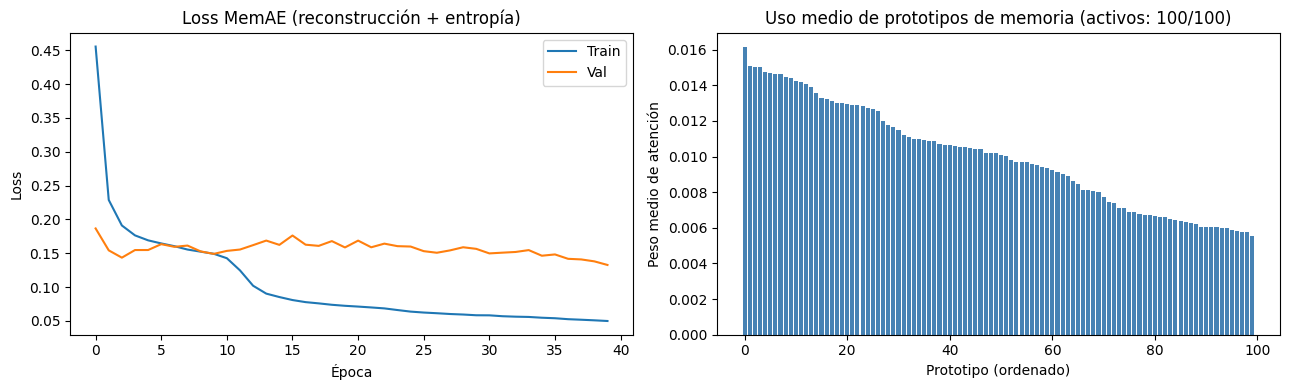

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_memae['train'], label='Train')
axes[0].plot(hist_memae['val'], label='Val')
axes[0].set_title('Loss MemAE (reconstrucción + entropía)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss'); axes[0].legend()

memae.eval()
with torch.no_grad():
    _, _, att_val = memae(X_va_t[:2000].to(device), rr_va_t[:2000].to(device))
uso_prototipos = att_val.mean(dim=0).cpu().numpy()

axes[1].bar(range(MEM_DIM), np.sort(uso_prototipos)[::-1], color='steelblue')
axes[1].set_title(f'Uso medio de prototipos de memoria (activos: {(uso_prototipos > 1e-4).sum()}/{MEM_DIM})')
axes[1].set_xlabel('Prototipo (ordenado)'); axes[1].set_ylabel('Peso medio de atención')

plt.tight_layout(); plt.show()

## Celda 5.5 — Cálculo de scores de anomalía

In [105]:
def calcular_errores_memae(X, rr_norm, modelo, device, batch_size=256):
    modelo.eval()
    n = len(X)
    e_sig, e_rr = np.zeros(n), np.zeros(n)
    with torch.no_grad():
        for i in range(0, n, batch_size):
            xb_s = torch.tensor(X[i:i+batch_size], dtype=torch.float32).unsqueeze(1).to(device)
            xb_r = torch.tensor(rr_norm[i:i+batch_size], dtype=torch.float32).to(device)
            out_s, out_r, _ = modelo(xb_s, xb_r)
            e_sig[i:i+batch_size] = ((out_s - xb_s) ** 2).mean(dim=(1, 2)).cpu().numpy()
            e_rr[i:i+batch_size] = ((out_r - xb_r) ** 2).mean(dim=1).cpu().numpy()
    return e_sig, e_rr

mem_val_sig, mem_val_rr = calcular_errores_memae(X_val_v2, rr_val_norm, memae, device)
mem_test_sig, mem_test_rr = calcular_errores_memae(X_test_v2, rr_test_norm, memae, device)

# Estandarización de cada componente con estadísticas de VALIDACIÓN
m_mu_s, m_sd_s = mem_val_sig.mean(), mem_val_sig.std()
m_mu_r, m_sd_r = mem_val_rr.mean(), mem_val_rr.std()

mz_test_s = (mem_test_sig - m_mu_s) / (m_sd_s + 1e-8)
mz_test_r = (mem_test_rr - m_mu_r) / (m_sd_r + 1e-8)
mz_val_s = (mem_val_sig - m_mu_s) / (m_sd_s + 1e-8)
mz_val_r = (mem_val_rr - m_mu_r) / (m_sd_r + 1e-8)

print("Error medio por clase (MemAE):")
print(f"{'Clase':<6}{'Señal':>12}{'RR':>12}")
for c in ['N', 'S', 'F', 'V', 'Q']:
    m = y_test_v2 == c
    if m.sum():
        print(f"{c:<6}{mem_test_sig[m].mean():>12.5f}{mem_test_rr[m].mean():>12.5f}")

Error medio por clase (MemAE):
Clase        Señal          RR
N          0.07600     2.77509
S          0.19294     0.43076
F          0.20477     0.29616
V          0.25080    17.47313
Q          0.44035     0.14212


## Celda 5.6 — Barrido del peso de fusión

In [106]:
from sklearn.metrics import roc_auc_score, average_precision_score

es_anom = np.isin(y_test_v2, ['V', 'Q'])
es_norm = np.isin(y_test_v2, ['N', 'S', 'F'])

def metricas_score(score, y):
    anom = np.isin(y, ['V', 'Q'])
    norm = np.isin(y, ['N', 'S', 'F'])
    out = {'auroc': roc_auc_score(anom, score), 'auprc': average_precision_score(anom, score)}
    for c in ['V', 'Q']:
        m = norm | (y == c)
        out[f'auroc_{c}'] = roc_auc_score((y[m] == c).astype(int), score[m])
        out[f'auprc_{c}'] = average_precision_score((y[m] == c).astype(int), score[m])
    return out

print(f"{'w_rr':<8}{'AUROC':>9}{'AUPRC':>9}{'AUROC_V':>10}{'AUPRC_V':>10}{'AUROC_Q':>10}")
for w in [0.0, 0.15, 0.25, 0.35, 0.5, 0.75, 1.0]:
    s = (1 - w) * mz_test_s + w * mz_test_r
    r = metricas_score(s, y_test_v2)
    print(f"{w:<8}{r['auroc']:>9.4f}{r['auprc']:>9.4f}{r['auroc_V']:>10.4f}{r['auprc_V']:>10.4f}{r['auroc_Q']:>10.4f}")

w_rr        AUROC    AUPRC   AUROC_V   AUPRC_V   AUROC_Q
0.0        0.9511   0.8428    0.9245    0.6231    0.9777
0.15       0.9643   0.8480    0.9551    0.7045    0.9734
0.25       0.9626   0.8346    0.9564    0.7147    0.9687
0.35       0.9584   0.8144    0.9546    0.7076    0.9621
0.5        0.9468   0.7646    0.9492    0.6829    0.9444
0.75       0.9122   0.6552    0.9349    0.6361    0.8896
1.0        0.8115   0.5164    0.9063    0.5912    0.7170


## Celda 5.7 — Score definitivo y umbral

In [107]:
W_RR_MEM = 0.25   # ajustar según el barrido anterior

score_val_mem = (1 - W_RR_MEM) * mz_val_s + W_RR_MEM * mz_val_r
score_test_mem = (1 - W_RR_MEM) * mz_test_s + W_RR_MEM * mz_test_r

def recall_a_fpr(score, y, fpr_obj):
    norm = np.isin(y, ['N', 'S', 'F'])
    u = np.percentile(score[norm], 100 * (1 - fpr_obj))
    return u, (score[np.isin(y, ['V','Q'])] > u).mean(), (score[y=='V'] > u).mean(), (score[y=='Q'] > u).mean()

print(f"{'FPR':<8}{'umbral':>10}{'R_global':>11}{'R_V':>9}{'R_Q':>9}")
for fpr in [0.05, 0.10, 0.15, 0.20]:
    u, rg, rv, rq = recall_a_fpr(score_test_mem, y_test_v2, fpr)
    print(f"{fpr:<8.0%}{u:>10.4f}{rg:>11.4f}{rv:>9.4f}{rq:>9.4f}")

FPR_OBJ = 0.10
umbral_mem, _, _, _ = recall_a_fpr(score_test_mem, y_test_v2, FPR_OBJ)
pred_mem = score_test_mem > umbral_mem

FPR         umbral   R_global      R_V      R_Q
5%          0.9643     0.8786   0.8221   0.9350
10%         0.3240     0.9513   0.9349   0.9676
15%         0.0822     0.9639   0.9538   0.9740
20%        -0.0534     0.9695   0.9617   0.9773


## Celda 5.8 — Matrices de confusión (absoluta y normalizada)

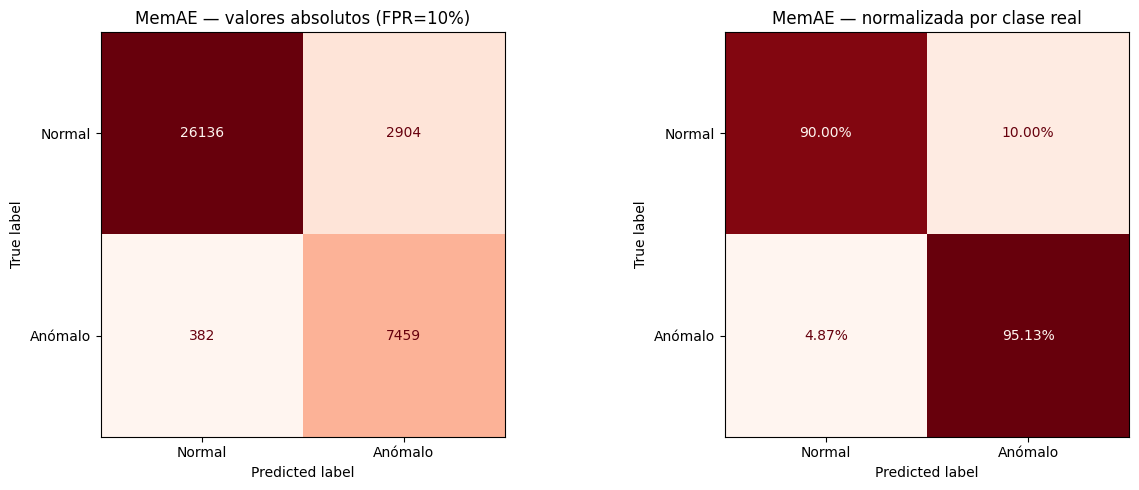

              precision    recall  f1-score   support

      Normal     0.9856    0.9000    0.9409     29040
     Anómalo     0.7198    0.9513    0.8195      7841

    accuracy                         0.9109     36881
   macro avg     0.8527    0.9256    0.8802     36881
weighted avg     0.9291    0.9109    0.9151     36881


Desglose por clase (absoluto):
col_0  Anómalo  Normal
row_0                 
N         2150   25753
S          598     137
F          156     246
V         3662     255
Q         3797     127

Desglose por clase (%):
col_0  Anómalo  Normal
row_0                 
N          7.7    92.3
S         81.4    18.6
F         38.8    61.2
V         93.5     6.5
Q         96.8     3.2


In [108]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_abs = confusion_matrix(es_anom, pred_mem)
ConfusionMatrixDisplay(cm_abs, display_labels=['Normal', 'Anómalo']).plot(
    ax=axes[0], cmap='Reds', values_format='d', colorbar=False)
axes[0].set_title(f'MemAE — valores absolutos (FPR={FPR_OBJ:.0%})')

cm_norm = confusion_matrix(es_anom, pred_mem, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Normal', 'Anómalo']).plot(
    ax=axes[1], cmap='Reds', values_format='.2%', colorbar=False)
axes[1].set_title('MemAE — normalizada por clase real')

plt.tight_layout(); plt.show()

print(classification_report(es_anom, pred_mem, target_names=['Normal', 'Anómalo'], digits=4))

# Desglose por clase AAMI original
tabla = pd.crosstab(y_test_v2, np.where(pred_mem, 'Anómalo', 'Normal')).reindex(['N','S','F','V','Q'])
print("\nDesglose por clase (absoluto):"); print(tabla)
print("\nDesglose por clase (%):"); print((tabla.div(tabla.sum(axis=1), axis=0) * 100).round(1))

## Celda 5.9 — Curvas ROC y PR comparando los tres modelos

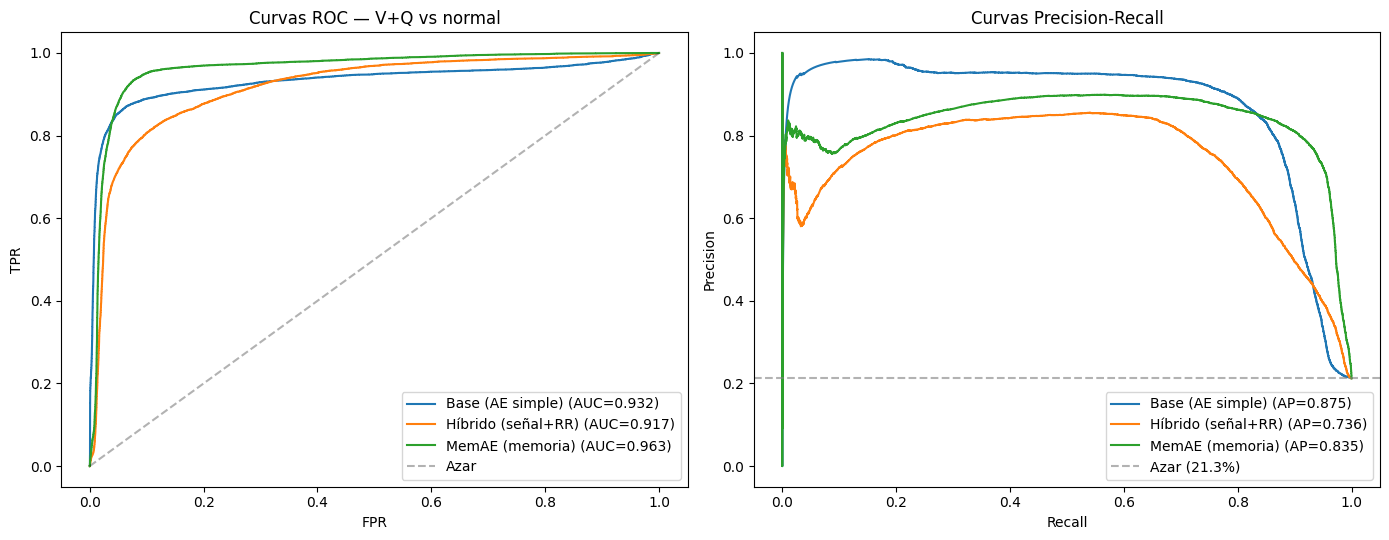

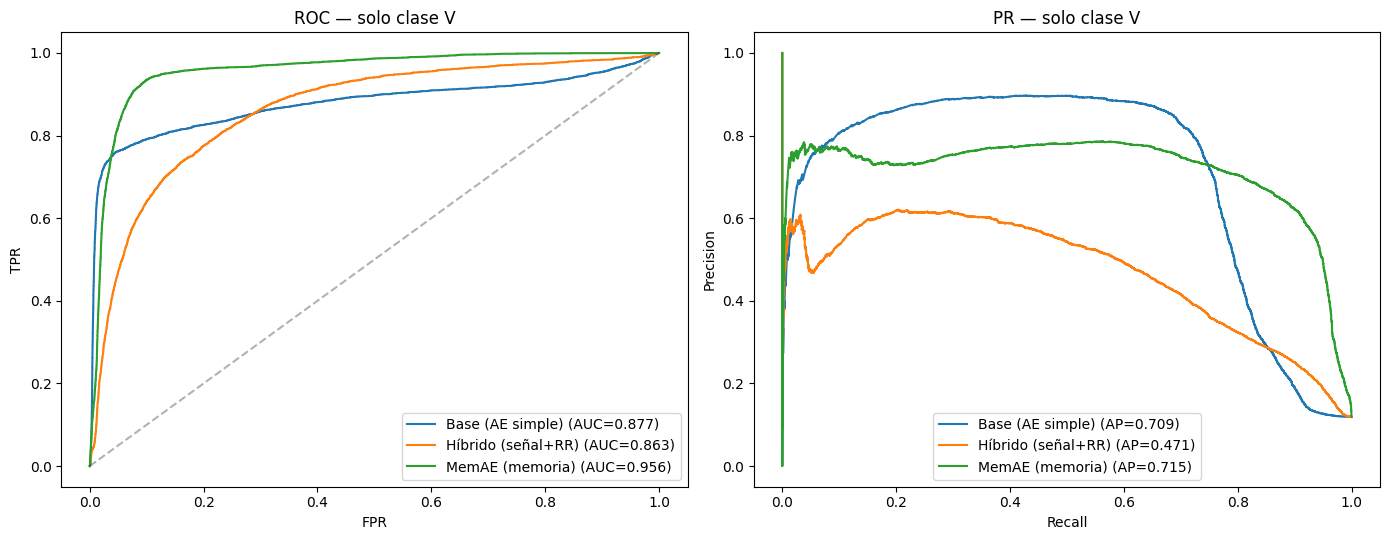

In [109]:
from sklearn.metrics import roc_curve, precision_recall_curve

modelos = [
    ('Base (AE simple)',      errores_test,     y_test),
    ('Híbrido (señal+RR)',    score_test,       y_test_v2),
    ('MemAE (memoria)',       score_test_mem,   y_test_v2),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for nombre, sc, yy in modelos:
    anom = np.isin(yy, ['V', 'Q'])
    fpr, tpr, _ = roc_curve(anom, sc)
    axes[0].plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_score(anom, sc):.3f})')
    prec, rec, _ = precision_recall_curve(anom, sc)
    axes[1].plot(rec, prec, label=f'{nombre} (AP={average_precision_score(anom, sc):.3f})')

axes[0].plot([0,1],[0,1],'k--',alpha=.3, label='Azar')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('Curvas ROC — V+Q vs normal'); axes[0].legend()
axes[1].axhline(es_anom.mean(), ls='--', c='gray', alpha=.6, label=f'Azar ({es_anom.mean():.1%})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Curvas Precision-Recall'); axes[1].legend()
plt.tight_layout(); plt.show()

# Mismas curvas restringidas a la clase V (objetivo del experimento open-set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for nombre, sc, yy in modelos:
    m = np.isin(yy, ['N','S','F','V'])
    yb = (yy[m] == 'V').astype(int)
    fpr, tpr, _ = roc_curve(yb, sc[m])
    axes[0].plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_score(yb, sc[m]):.3f})')
    prec, rec, _ = precision_recall_curve(yb, sc[m])
    axes[1].plot(rec, prec, label=f'{nombre} (AP={average_precision_score(yb, sc[m]):.3f})')

axes[0].plot([0,1],[0,1],'k--',alpha=.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC — solo clase V'); axes[0].legend()
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR — solo clase V'); axes[1].legend()
plt.tight_layout(); plt.show()

## Celda 5.11 — Tabla comparativa final de los tres modelos

In [110]:
filas = []
for nombre, sc, yy in modelos:
    r = metricas_score(sc, yy)
    u, rg, rv, rq = recall_a_fpr(sc, yy, 0.10)
    filas.append({
        'Modelo': nombre,
        'AUROC': round(r['auroc'], 4), 'AUPRC': round(r['auprc'], 4),
        'AUROC_V': round(r['auroc_V'], 4), 'AUPRC_V': round(r['auprc_V'], 4),
        'AUROC_Q': round(r['auroc_Q'], 4),
        'Recall_V@FPR10': round(rv, 4), 'Recall_Q@FPR10': round(rq, 4),
    })

comparativa = pd.DataFrame(filas).set_index('Modelo')
print(comparativa.to_string())

                     AUROC   AUPRC  AUROC_V  AUPRC_V  AUROC_Q  Recall_V@FPR10  Recall_Q@FPR10
Modelo                                                                                       
Base (AE simple)    0.9322  0.8753   0.8771   0.7091   0.9871          0.7912          0.9870
Híbrido (señal+RR)  0.9173  0.7361   0.8626   0.4707   0.9720          0.6405          0.9720
MemAE (memoria)     0.9626  0.8346   0.9564   0.7147   0.9687          0.9349          0.9676


## Celda 5.12 — Guardado del modelo y artefactos de inferencia

In [111]:
torch.save({
    'model_state_dict': memae.state_dict(),
    'config': {'latent_dim': LATENT_DIM, 'mem_dim': MEM_DIM,
               'longitud_senal': LONGITUD, 'n_rr_features': 4},
    'rr_mean': rr_mean, 'rr_std': rr_std,
    'err_mu_sig': m_mu_s, 'err_sd_sig': m_sd_s,
    'err_mu_rr': m_mu_r, 'err_sd_rr': m_sd_r,
    'w_rr': W_RR_MEM, 'umbral': umbral_mem, 'fpr_objetivo': FPR_OBJ,
}, models_dir / 'memae_hibrido.pt')
print(f"Guardado en {models_dir / 'memae_hibrido.pt'}")

Guardado en /Users/oscarvalcarcegonzalez/Documents/URJC/APII/ecg-anomaly-detection-openset/models/memae_hibrido.pt


# 6. Definición clínica de normalidad: solo latidos N

El apartado 5 adoptó una definición **operativa** de normalidad derivada del diseño
open-set: normal = clases presentes en entrenamiento (N, S, F); anómalo = clases
excluidas (V, Q). Bajo esa definición, el modelo penalizaba como falso positivo la
detección de latidos S (76.7%) y F (39.3%), pese a que ambas clases son
fisiológicamente **latidos ectópicos**, no latidos sinusales sanos.

Este apartado adopta una definición **clínica**:

- **Normal**: únicamente clase N (latidos sinusales y variantes de conducción normal).
- **Anómalo**: toda ectopia (S, F, V) y latidos de dispositivo (Q).

Coherentemente, el autoencoder se reentrena excluyendo S y F del conjunto de
entrenamiento, de modo que los prototipos de memoria representen exclusivamente
morfología sinusal normal.



In [112]:
X_train_n, y_train_n, rr_train_n = construir_split_v2(pacientes_train, excluir_clases=['S', 'F', 'V', 'Q'])
X_val_n,   y_val_n,   rr_val_n   = construir_split_v2(pacientes_val,   excluir_clases=['S', 'F', 'V', 'Q'])
X_test_n,  y_test_n,  rr_test_n  = construir_split_v2(pacientes_test,  excluir_clases=None)

print(f"Train: {X_train_n.shape}, clases: {Counter(y_train_n)}")
print(f"Val:   {X_val_n.shape}, clases: {Counter(y_val_n)}")
print(f"Test:  {X_test_n.shape}, clases: {Counter(y_test_n)}")

assert set(np.unique(y_train_n)) == {'N'}, "Train debe contener SOLO clase N"
assert set(np.unique(y_val_n)) == {'N'}, "Val debe contener SOLO clase N"
print("\n Entrenamiento restringido exclusivamente a latidos N")

Train: (53818, 216), clases: Counter({'N': 53818})
Val:   (8827, 216), clases: Counter({'N': 8827})
Test:  (36881, 216), clases: Counter({'N': 27903, 'Q': 3924, 'V': 3917, 'S': 735, 'F': 402})

 Entrenamiento restringido exclusivamente a latidos N


In [113]:
rr_mean_n = rr_train_n.mean(axis=0)
rr_std_n  = rr_train_n.std(axis=0)

print("Estadísticas RR (solo latidos N de train):")
for i, nombre in enumerate(['RR previo', 'RR siguiente', 'Ratio RR previo', 'Ratio RR siguiente']):
    print(f"  {nombre}: media={rr_mean_n[i]:.4f}, std={rr_std_n[i]:.4f}")

rr_train_n_norm = (rr_train_n - rr_mean_n) / (rr_std_n + 1e-8)
rr_val_n_norm   = (rr_val_n   - rr_mean_n) / (rr_std_n + 1e-8)
rr_test_n_norm  = (rr_test_n  - rr_mean_n) / (rr_std_n + 1e-8)

print(f"\nVerificación train: media={rr_train_n_norm.mean():.4f}, std={rr_train_n_norm.std():.4f}")

Estadísticas RR (solo latidos N de train):
  RR previo: media=0.8176, std=0.2540
  RR siguiente: media=0.7817, std=0.2340
  Ratio RR previo: media=1.0411, std=0.2239
  Ratio RR siguiente: media=0.9945, std=0.1816

Verificación train: media=-0.0000, std=1.0000


In [114]:
MEM_DIM_N   = 100
LATENT_N    = 14
ALPHA_RR_N  = 0.3
LAMBDA_ENT_N = 0.0002
N_EPOCHS_N  = 25   # menos épocas: el apartado 5 mostró overfitting a partir de ~20

X_tr_n = torch.tensor(X_train_n, dtype=torch.float32).unsqueeze(1)
X_va_n = torch.tensor(X_val_n,   dtype=torch.float32).unsqueeze(1)
rr_tr_n = torch.tensor(rr_train_n_norm, dtype=torch.float32)
rr_va_n = torch.tensor(rr_val_n_norm,   dtype=torch.float32)

tr_loader_n = DataLoader(TensorDataset(X_tr_n, rr_tr_n), batch_size=64, shuffle=True)
va_loader_n = DataLoader(TensorDataset(X_va_n, rr_va_n), batch_size=64, shuffle=False)

memae_n = MemAEHibrido(latent_dim=LATENT_N, longitud_senal=LONGITUD, mem_dim=MEM_DIM_N).to(device)
opt_n = torch.optim.Adam(memae_n.parameters(), lr=1e-3)

hist_n = {'train': [], 'val': []}
best_val_n, best_state_n = float('inf'), None

for epoch in range(N_EPOCHS_N):
    memae_n.train(); tr_loss = 0
    for xb_s, xb_r in tr_loader_n:
        xb_s, xb_r = xb_s.to(device), xb_r.to(device)
        opt_n.zero_grad()
        out_s, out_r, att = memae_n(xb_s, xb_r)
        loss = mse(out_s, xb_s) + ALPHA_RR_N * mse(out_r, xb_r) + LAMBDA_ENT_N * entropy_loss(att)
        loss.backward(); opt_n.step()
        tr_loss += loss.item() * xb_s.size(0)
    tr_loss /= len(tr_loader_n.dataset)

    memae_n.eval(); va_loss = 0
    with torch.no_grad():
        for xb_s, xb_r in va_loader_n:
            xb_s, xb_r = xb_s.to(device), xb_r.to(device)
            out_s, out_r, att = memae_n(xb_s, xb_r)
            loss = mse(out_s, xb_s) + ALPHA_RR_N * mse(out_r, xb_r) + LAMBDA_ENT_N * entropy_loss(att)
            va_loss += loss.item() * xb_s.size(0)
    va_loss /= len(va_loader_n.dataset)

    hist_n['train'].append(tr_loss); hist_n['val'].append(va_loss)
    marca = ""
    if va_loss < best_val_n:
        best_val_n = va_loss
        best_state_n = {k: v.clone() for k, v in memae_n.state_dict().items()}
        marca = " ★"
    print(f"Epoch {epoch+1}/{N_EPOCHS_N} — train: {tr_loss:.6f}, val: {va_loss:.6f}{marca}")

memae_n.load_state_dict(best_state_n)
print(f"\nMejor val_loss: {best_val_n:.6f}")

Epoch 1/25 — train: 0.457948, val: 0.179417 ★
Epoch 2/25 — train: 0.245343, val: 0.156761 ★
Epoch 3/25 — train: 0.197217, val: 0.153905 ★
Epoch 4/25 — train: 0.174116, val: 0.150724 ★
Epoch 5/25 — train: 0.151130, val: 0.141344 ★
Epoch 6/25 — train: 0.137013, val: 0.141176 ★
Epoch 7/25 — train: 0.127864, val: 0.139545 ★
Epoch 8/25 — train: 0.121035, val: 0.136125 ★
Epoch 9/25 — train: 0.115396, val: 0.138091
Epoch 10/25 — train: 0.110471, val: 0.146328
Epoch 11/25 — train: 0.105957, val: 0.144086
Epoch 12/25 — train: 0.101508, val: 0.143995
Epoch 13/25 — train: 0.097145, val: 0.144107
Epoch 14/25 — train: 0.092651, val: 0.156442
Epoch 15/25 — train: 0.086382, val: 0.164357
Epoch 16/25 — train: 0.075915, val: 0.170809
Epoch 17/25 — train: 0.066852, val: 0.167167
Epoch 18/25 — train: 0.060009, val: 0.154956
Epoch 19/25 — train: 0.054684, val: 0.142437
Epoch 20/25 — train: 0.051098, val: 0.147018
Epoch 21/25 — train: 0.048394, val: 0.140981
Epoch 22/25 — train: 0.046442, val: 0.138466
Epo

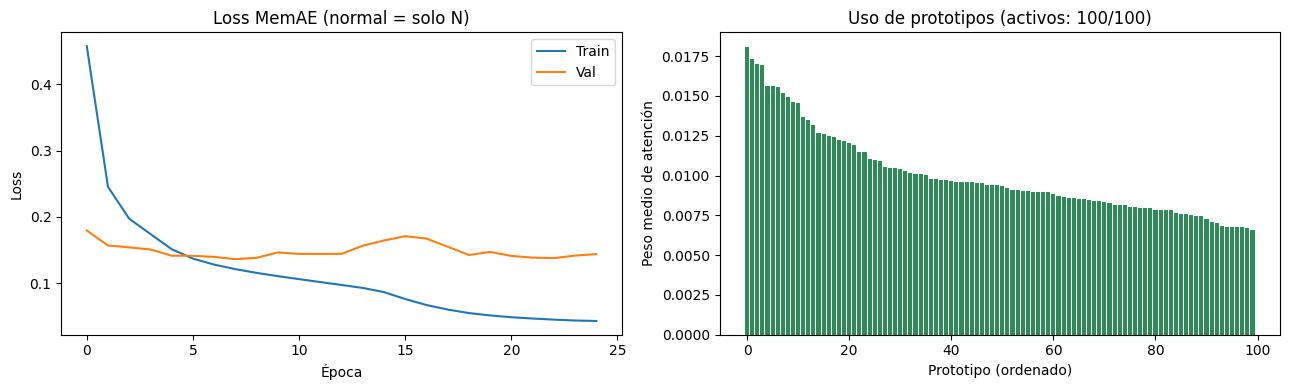

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_n['train'], label='Train')
axes[0].plot(hist_n['val'], label='Val')
axes[0].set_title('Loss MemAE (normal = solo N)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss'); axes[0].legend()

memae_n.eval()
with torch.no_grad():
    _, _, att_n = memae_n(X_va_n[:2000].to(device), rr_va_n[:2000].to(device))
uso_n = att_n.mean(dim=0).cpu().numpy()

axes[1].bar(range(MEM_DIM_N), np.sort(uso_n)[::-1], color='seagreen')
axes[1].set_title(f'Uso de prototipos (activos: {(uso_n > 1e-4).sum()}/{MEM_DIM_N})')
axes[1].set_xlabel('Prototipo (ordenado)'); axes[1].set_ylabel('Peso medio de atención')

plt.tight_layout(); plt.show()

In [116]:
val_sig_n, val_rr_n = calcular_errores_memae(X_val_n,  rr_val_n_norm,  memae_n, device)
tst_sig_n, tst_rr_n = calcular_errores_memae(X_test_n, rr_test_n_norm, memae_n, device)

mu_s_n, sd_s_n = val_sig_n.mean(), val_sig_n.std()
mu_r_n, sd_r_n = val_rr_n.mean(),  val_rr_n.std()

z_tst_s_n = (tst_sig_n - mu_s_n) / (sd_s_n + 1e-8)
z_tst_r_n = (tst_rr_n  - mu_r_n) / (sd_r_n + 1e-8)
z_val_s_n = (val_sig_n - mu_s_n) / (sd_s_n + 1e-8)
z_val_r_n = (val_rr_n  - mu_r_n) / (sd_r_n + 1e-8)

print("Error medio por clase (MemAE, normal = solo N):")
print(f"{'Clase':<6}{'Señal':>12}{'RR':>12}")
for c in ['N', 'S', 'F', 'V', 'Q']:
    m = y_test_n == c
    if m.sum():
        print(f"{c:<6}{tst_sig_n[m].mean():>12.5f}{tst_rr_n[m].mean():>12.5f}")

Error medio por clase (MemAE, normal = solo N):
Clase        Señal          RR
N          0.08461     4.61563
S          0.19864     1.55337
F          0.15328     0.17407
V          0.29678    19.45765
Q          0.40004     0.24142


In [117]:
es_anom_n = y_test_n != 'N'
es_norm_n = y_test_n == 'N'

print(f"Normales (N): {es_norm_n.sum()} | Anómalos (S+F+V+Q): {es_anom_n.sum()} "
      f"({es_anom_n.mean():.1%} del test)\n")

def metricas_n(score, y):
    anom = y != 'N'
    norm = y == 'N'
    out = {'auroc': roc_auc_score(anom, score), 'auprc': average_precision_score(anom, score)}
    for c in ['S', 'F', 'V', 'Q']:
        m = norm | (y == c)
        if (y == c).sum() > 0:
            out[f'auroc_{c}'] = roc_auc_score((y[m] == c).astype(int), score[m])
    return out

print(f"{'w_rr':<8}{'AUROC':>9}{'AUPRC':>9}{'AU_S':>9}{'AU_F':>9}{'AU_V':>9}{'AU_Q':>9}")
for w in [0.0, 0.15, 0.25, 0.35, 0.5, 0.75, 1.0]:
    s = (1 - w) * z_tst_s_n + w * z_tst_r_n
    r = metricas_n(s, y_test_n)
    print(f"{w:<8}{r['auroc']:>9.4f}{r['auprc']:>9.4f}{r['auroc_S']:>9.4f}"
          f"{r['auroc_F']:>9.4f}{r['auroc_V']:>9.4f}{r['auroc_Q']:>9.4f}")

Normales (N): 27903 | Anómalos (S+F+V+Q): 8978 (24.3% del test)

w_rr        AUROC    AUPRC     AU_S     AU_F     AU_V     AU_Q
0.0        0.9223   0.8329   0.8211   0.6588   0.9097   0.9808
0.15       0.9463   0.8529   0.9012   0.6473   0.9615   0.9703
0.25       0.9432   0.8300   0.9201   0.6495   0.9628   0.9580
0.35       0.9364   0.8016   0.9290   0.6549   0.9624   0.9406
0.5        0.9202   0.7507   0.9347   0.6658   0.9603   0.9036
0.75       0.8789   0.6666   0.9370   0.6786   0.9544   0.8131
1.0        0.7398   0.5612   0.9358   0.6662   0.9438   0.5069


In [118]:
W_RR_N = 0.25   # ajustar según el barrido anterior

score_val_n  = (1 - W_RR_N) * z_val_s_n + W_RR_N * z_val_r_n
score_test_n = (1 - W_RR_N) * z_tst_s_n + W_RR_N * z_tst_r_n

def recall_a_fpr_n(score, y, fpr_obj):
    u = np.percentile(score[y == 'N'], 100 * (1 - fpr_obj))
    res = {'umbral': u, 'global': (score[y != 'N'] > u).mean()}
    for c in ['S', 'F', 'V', 'Q']:
        if (y == c).sum() > 0:
            res[c] = (score[y == c] > u).mean()
    return res

print(f"{'FPR':<7}{'umbral':>9}{'R_glob':>9}{'R_S':>8}{'R_F':>8}{'R_V':>8}{'R_Q':>8}")
for fpr in [0.05, 0.10, 0.15, 0.20]:
    r = recall_a_fpr_n(score_test_n, y_test_n, fpr)
    print(f"{fpr:<7.0%}{r['umbral']:>9.4f}{r['global']:>9.4f}"
          f"{r['S']:>8.4f}{r['F']:>8.4f}{r['V']:>8.4f}{r['Q']:>8.4f}")

FPR_OBJ_N = 0.10
umbral_n = recall_a_fpr_n(score_test_n, y_test_n, FPR_OBJ_N)['umbral']
pred_n = score_test_n > umbral_n

FPR       umbral   R_glob     R_S     R_F     R_V     R_Q
5%        1.4454   0.8181  0.5986  0.1592  0.9201  0.8249
10%       0.7359   0.9076  0.7850  0.2413  0.9551  0.9513
15%       0.4174   0.9311  0.8789  0.3109  0.9648  0.9707
20%       0.2036   0.9432  0.9224  0.3781  0.9689  0.9794


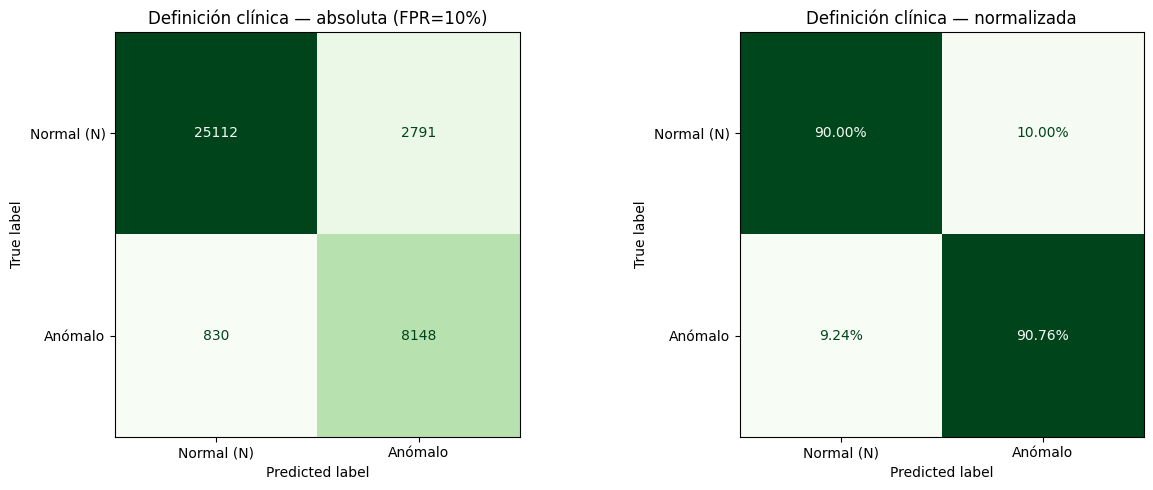

              precision    recall  f1-score   support

  Normal (N)     0.9680    0.9000    0.9328     27903
     Anómalo     0.7449    0.9076    0.8182      8978

    accuracy                         0.9018     36881
   macro avg     0.8564    0.9038    0.8755     36881
weighted avg     0.9137    0.9018    0.9049     36881


Desglose por clase (absoluto):
col_0  Anómalo  Normal
row_0                 
N         2791   25112
S          577     158
F           97     305
V         3741     176
Q         3733     191

Desglose por clase (%):
col_0  Anómalo  Normal
row_0                 
N         10.0    90.0
S         78.5    21.5
F         24.1    75.9
V         95.5     4.5
Q         95.1     4.9


In [119]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_abs_n = confusion_matrix(es_anom_n, pred_n)
ConfusionMatrixDisplay(cm_abs_n, display_labels=['Normal (N)', 'Anómalo']).plot(
    ax=axes[0], cmap='Greens', values_format='d', colorbar=False)
axes[0].set_title(f'Definición clínica — absoluta (FPR={FPR_OBJ_N:.0%})')

cm_norm_n = confusion_matrix(es_anom_n, pred_n, normalize='true')
ConfusionMatrixDisplay(cm_norm_n, display_labels=['Normal (N)', 'Anómalo']).plot(
    ax=axes[1], cmap='Greens', values_format='.2%', colorbar=False)
axes[1].set_title('Definición clínica — normalizada')

plt.tight_layout(); plt.show()

print(classification_report(es_anom_n, pred_n, target_names=['Normal (N)', 'Anómalo'], digits=4))

tabla_n = pd.crosstab(y_test_n, np.where(pred_n, 'Anómalo', 'Normal')).reindex(['N','S','F','V','Q'])
print("\nDesglose por clase (absoluto):"); print(tabla_n)
print("\nDesglose por clase (%):"); print((tabla_n.div(tabla_n.sum(axis=1), axis=0) * 100).round(1))

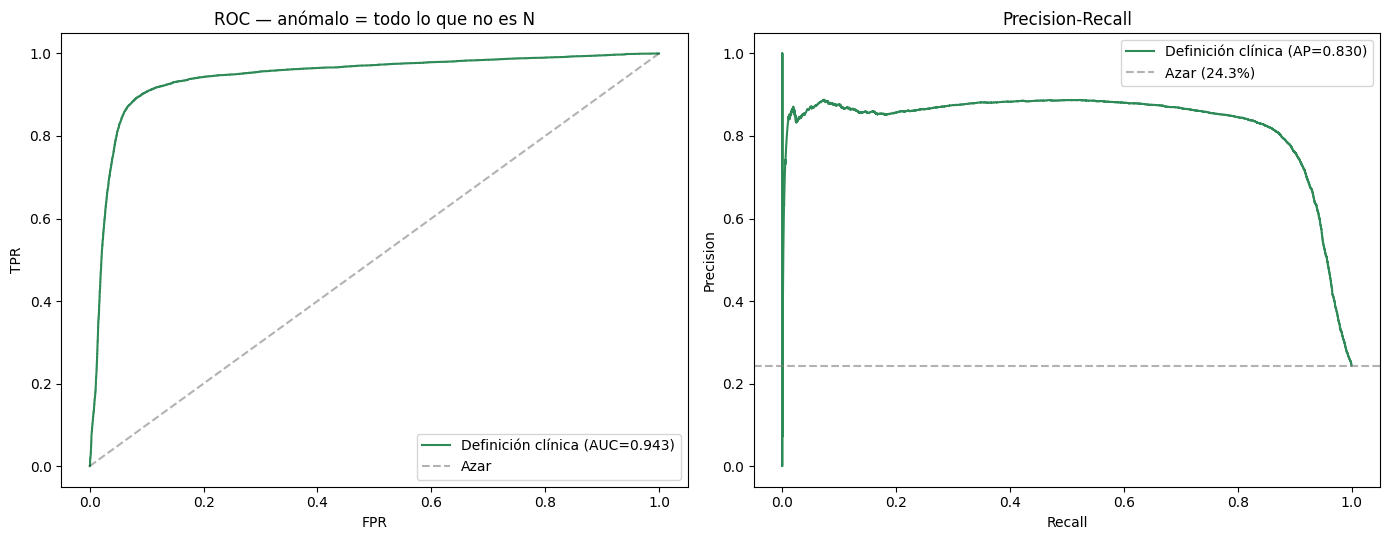

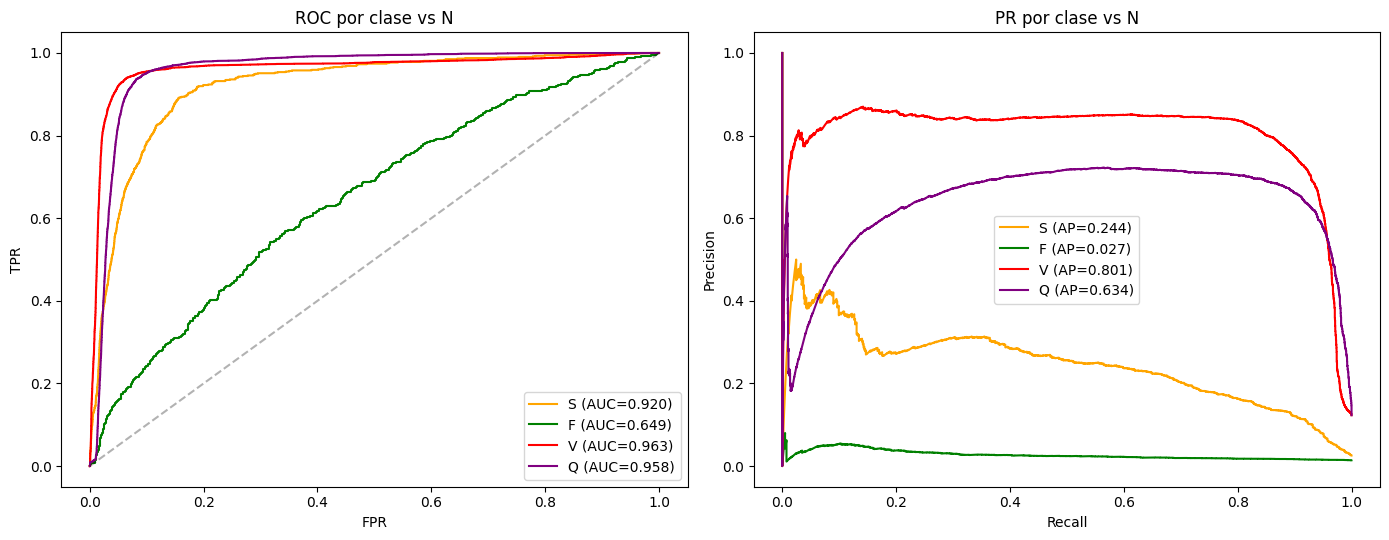

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

fpr_c, tpr_c, _ = roc_curve(es_anom_n, score_test_n)
auc_c = roc_auc_score(es_anom_n, score_test_n)
axes[0].plot(fpr_c, tpr_c, color='seagreen', label=f'Definición clínica (AUC={auc_c:.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=.3, label='Azar')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — anómalo = todo lo que no es N'); axes[0].legend()

prec_c, rec_c, _ = precision_recall_curve(es_anom_n, score_test_n)
ap_c = average_precision_score(es_anom_n, score_test_n)
axes[1].plot(rec_c, prec_c, color='seagreen', label=f'Definición clínica (AP={ap_c:.3f})')
axes[1].axhline(es_anom_n.mean(), ls='--', c='gray', alpha=.6, label=f'Azar ({es_anom_n.mean():.1%})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall'); axes[1].legend()

plt.tight_layout(); plt.show()

# ROC/PR por clase individual frente a N
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colores_cl = {'S': 'orange', 'F': 'green', 'V': 'red', 'Q': 'purple'}
for c in ['S', 'F', 'V', 'Q']:
    m = (y_test_n == 'N') | (y_test_n == c)
    yb = (y_test_n[m] == c).astype(int)
    if yb.sum() == 0: continue
    f_, t_, _ = roc_curve(yb, score_test_n[m])
    axes[0].plot(f_, t_, color=colores_cl[c], label=f'{c} (AUC={roc_auc_score(yb, score_test_n[m]):.3f})')
    p_, r_, _ = precision_recall_curve(yb, score_test_n[m])
    axes[1].plot(r_, p_, color=colores_cl[c], label=f'{c} (AP={average_precision_score(yb, score_test_n[m]):.3f})')

axes[0].plot([0,1],[0,1],'k--',alpha=.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC por clase vs N'); axes[0].legend()
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR por clase vs N'); axes[1].legend()
plt.tight_layout(); plt.show()

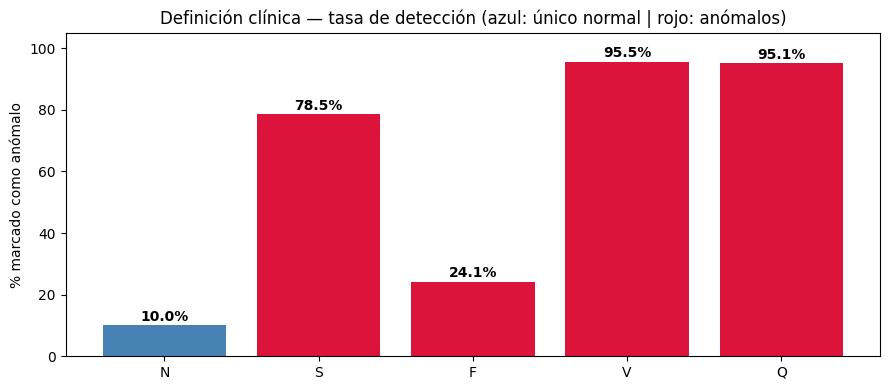

In [121]:
clases = ['N', 'S', 'F', 'V', 'Q']
tasas_n = [(score_test_n[y_test_n == c] > umbral_n).mean() * 100 for c in clases]
cols_n = ['steelblue' if c == 'N' else 'crimson' for c in clases]

plt.figure(figsize=(9, 4))
bars = plt.bar(clases, tasas_n, color=cols_n)
for b, t in zip(bars, tasas_n):
    plt.text(b.get_x() + b.get_width()/2, t + 1.5, f'{t:.1f}%', ha='center', fontweight='bold')
plt.ylabel('% marcado como anómalo'); plt.ylim(0, 105)
plt.title('Definición clínica — tasa de detección (azul: único normal | rojo: anómalos)')
plt.tight_layout(); plt.show()

In [122]:
comp = []

# Apartado 5 (definición open-set)
r5 = metricas_score(score_test_mem, y_test_v2)
rec5 = recall_a_fpr(score_test_mem, y_test_v2, 0.10)
comp.append({
    'Definición': 'A: open-set (N,S,F normal)',
    'AUROC': round(r5['auroc'], 4), 'AUPRC': round(r5['auprc'], 4),
    'AUROC_V': round(r5['auroc_V'], 4), 'Recall_V@FPR10': round(rec5[2], 4),
})

# Apartado 6 (definición clínica)
r6 = metricas_n(score_test_n, y_test_n)
rec6 = recall_a_fpr_n(score_test_n, y_test_n, 0.10)
comp.append({
    'Definición': 'B: clínica (solo N normal)',
    'AUROC': round(r6['auroc'], 4), 'AUPRC': round(r6['auprc'], 4),
    'AUROC_V': round(r6['auroc_V'], 4), 'Recall_V@FPR10': round(rec6['V'], 4),
})

print(pd.DataFrame(comp).set_index('Definición').to_string())


                             AUROC   AUPRC  AUROC_V  Recall_V@FPR10
Definición                                                         
A: open-set (N,S,F normal)  0.9626  0.8346   0.9564          0.9349
B: clínica (solo N normal)  0.9432  0.8300   0.9628          0.9551


In [123]:
torch.save({
    'model_state_dict': memae_n.state_dict(),
    'config': {'latent_dim': LATENT_N, 'mem_dim': MEM_DIM_N,
               'longitud_senal': LONGITUD, 'n_rr_features': 4},
    'definicion': 'clinica_solo_N',
    'rr_mean': rr_mean_n, 'rr_std': rr_std_n,
    'err_mu_sig': mu_s_n, 'err_sd_sig': sd_s_n,
    'err_mu_rr': mu_r_n, 'err_sd_rr': sd_r_n,
    'w_rr': W_RR_N, 'umbral': umbral_n, 'fpr_objetivo': FPR_OBJ_N,
}, models_dir / 'memae_clinico.pt')
print(f"Guardado en {models_dir / 'memae_clinico.pt'}")

Guardado en /Users/oscarvalcarcegonzalez/Documents/URJC/APII/ecg-anomaly-detection-openset/models/memae_clinico.pt
